# 2 ЛАБОРАТОРНАЯ РАБОТА ПО ФРЕЙМВОРКАМ ДЛЯ ML
### Выполнена студентом 102 группы, Дубчаком Александром.

```
Отдельные слова благодарности преподавателю Амелии Вадимовне за такую крутую задумку в стиле Cicada 3301 ;)))
```

### С помощью библиотек pandas, openpyxl получим доступ ко всем excel-листам датафрейма.

Сперва, на первом листе выделим все ячейки и поставим черный шрифт для того чтобы данные ячеек стали видны. Теперь все колонки приняли человеческий вид, кроме колонок "City", "Unnamed: 20", "Unnamed: 24". Дело в том, по всему листу разбросаны куски датасета, которые впоследствии придется собрать в единый датасет, но для начала решим проблему с колонками. Очевидно, сбита кодировка, для восстановления кодировки текста в ячейках этих колонках с помощью библиотек pandas и openpyxl сделаем следующее:

In [75]:
import pandas as pd

df = pd.read_excel("have_fun.xlsx", sheet_name=None)

def fix_text(s):
    if not isinstance(s, str):
        return s
    try:
        return s.encode("latin1").decode("cp1251")
    except:
        return s

for name, sheet in df.items():
    print("Лист:", name)
    print("Колонки:", list(sheet.columns))
    for col in sheet.columns:
        if str(col).strip().lower() == "city" or str(col).strip() == "Unnamed: 20" or str(col).strip() == "Unnamed: 24":
            sheet[col] = sheet[col].apply(fix_text)

with pd.ExcelWriter("fixed_2_have_fun.xlsx") as writer:
    for name, sheet in df.items():
        sheet.to_excel(writer, sheet_name=name, index=False)

Лист: Ëèñò1
Колонки: ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'ds', 'city']
Лист: Лист1
Колонки: []
Лист: ÌÀÈ
Колонки: []
Лист: ýòî
Колонки: []
Лист: ÿ
Колонки: []
Лист: !
Колонки: []
Лист: Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû
Колонки: ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'ds', 'city', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24']
Лист: Ëèñò3_ñìåøàííûå_òèïû
Колонки: ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'ds', 'city']


После того как мы получили исправленный Excel-файл "fixed_2_have_fun.xlsx", отсортируем листы в порядке значимости: пустые листы убираем в конец, после чего остается 3 листа, с которыми предстоит продолжить работу. 

Далее, перекодируем названия этих трех листов:

In [67]:
name1 = "Ëèñò1"
print(name1.encode("latin1").decode("cp1251"))
name2 = "Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû"
print(name2.encode("latin1").decode("cp1251"))
name3 = "Ëèñò3_ñìåøàííûå_òèïû"
print(name3.encode("latin1").decode("cp1251"))

Лист1
Лист2_строковые_NaN_выбросы
Лист3_смешанные_типы


Далее, некая часть кусочного датасета вставляется вместо картинки с котиком, другая часть является дубликатом уже имещихся данных на своем месте. Часть куска датасета, где в колонке city значатся Благовещенск и Геленджик, отправляется в первый лист, так как на втором листе присутствуют данные, значения которых в колонке city - Москва, Находка, в отличие от листа 1.

Для полного восстановления датасета лишь осталось удалить пустые строки между строками данных.

Удаление пустых строк:

In [76]:
import pandas as pd

df = pd.read_excel("fixed_2_have_fun.xlsx", sheet_name=None)

# удаляем полностью пустые строки
for name, sheet in df.items():
    sheet = sheet.replace(r'^\s*$', pd.NA, regex=True)
    df[name] = sheet.dropna(how='all')

# сохраняем НОВЫЙ файл
with pd.ExcelWriter("clean_have_fun.xlsx", engine="openpyxl") as writer:
    for name, sheet in df.items():
        sheet.to_excel(writer, sheet_name=name, index=False)

На данном этапе был успешно восстановлен доступ ко всем данным Excel-файла, включая скрытые листы. Были исправлены проблемы кодировки, проверена корректность временных меток и уникальность наблюдений по комбинации город–время. После восстановления датасет стал пригоден для дальнейшей предобработки и анализа временных рядов.

# Предобработка данных

Проверим, есть ли дубликаты на наших 3 листах с данными. Проверим это в Excel с помощью формулы:

```=IF(AND(J4=J5, I4=I5), 1, K3)```

![alt text](<Screenshot 2026-05-09 at 1.38.45 PM.png>)
![alt text](<Screenshot 2026-05-09 at 1.39.03 PM.png>)
![alt text](<Screenshot 2026-05-09 at 1.39.16 PM.png>)

Как видно по результату, дубликаты есть только на первом листе. Удалим их:

In [77]:
for name, sheet in df.items():
    if 'city' in sheet.columns and 'ds' in sheet.columns:
        df[name] = sheet.drop_duplicates(subset=['city', 'ds'])

Исправим ошибки в названиях городов на каждом листе:

In [ ]:
for name, sheet in df.items():
    if "city" in sheet.columns:
        sheet["city"] = sheet["city"].replace(["nan", "NaN", "None", ""], pd.NA)
        sheet["city"] = sheet["city"].str.strip().str.title()
        sheet["city"] = sheet["city"].replace({
            "Благовещенс": "Благовещенск",
            "Благовещенскк": "Благовещенск",
            "Геленджи": "Геленджик",
            "Геленджикк": "Геленджик",
            "Мосва": "Москва",
            "Соч": "Сочи",
            "Счи": "Сочи",
            "Сычи": "Сочи"
        })
        sheet = sheet.dropna(subset=["city"])
        df[name] = sheet

with pd.ExcelWriter("cleaned_2_have_fun.xlsx", engine="openpyxl") as writer:
    for name, sheet in df.items():
        if sheet.index.name == "ds":
            sheet.reset_index().to_excel(writer, sheet_name=name, index=False)
        else:
            sheet.to_excel(writer, sheet_name=name, index=False)

for name, sheet in df.items():
    if "city" in sheet.columns:
        print(name)
        print(sheet["city"].unique())
        print("=" * 44)

Лист1
<ArrowStringArray>
['Геленджик', 'Благовещенск']
Length: 2, dtype: str
Лист2_строковые_NaN_выбросы
<ArrowStringArray>
['Москва', 'Находка']
Length: 2, dtype: str
Лист3_смешанные_типы
<ArrowStringArray>
['Санкт-Петербург', 'Сочи']
Length: 2, dtype: str


Проверяем пропуски в колонках city:

In [8]:
import pandas as pd
df = pd.read_excel("cleaned_2_have_fun.xlsx", sheet_name=None)
for name, sheet in df.items():
    if "city" in sheet.columns:
        print(name, sheet["city"].isna().sum())

Лист1 0
Лист2_строковые_NaN_выбросы 0
Лист3_смешанные_типы 0


Как и ожидалось, пропусков в колонках city нет, поэтому приведем данные к единому временному индексу, отсортируем их по времени, поставим в качестве индекса датафрейма время и приведем данные к ежедневной частоте:

In [9]:
for name, sheet in df.items():
    if "ds" in sheet.columns and "city" in sheet.columns:
        sheet["ds"] = pd.to_datetime(sheet["ds"])
        sheet = sheet.sort_values(["city", "ds"])

        parts = []

        for city, city_df in sheet.groupby("city"):
            city_df = city_df.sort_values("ds")
            city_df = city_df.set_index("ds")
            city_df = city_df.asfreq("h")
            city_df["city"] = city 

            parts.append(city_df)           
                                
        df[name] = pd.concat(parts)

Займемся обработкой пропусков числовых признаков. Для начала оценим число строк с пропущенными числовыми признаками:

In [10]:
numeric_cols = ["temperature_2m", "relative_humidity_2m", "precipitation", "rain", "snowfall", "weathercode", "wind_speed_10m", "surface_pressure", "ds"]

for name, sheet in df.items():
    print(f"\nЛист: {name}")

    for col in numeric_cols:
        if col in sheet.columns: # числовые признаки
            missing = sheet[col].isna().sum()
            print(f"{col}: {missing}")


Лист: Лист1
temperature_2m: 1841
relative_humidity_2m: 0
precipitation: 1227
rain: 0
snowfall: 0
weathercode: 0
wind_speed_10m: 1227
surface_pressure: 0

Лист: Лист2_строковые_NaN_выбросы
temperature_2m: 683
relative_humidity_2m: 4
precipitation: 690
rain: 4
snowfall: 4
weathercode: 4
wind_speed_10m: 354
surface_pressure: 4

Лист: Лист3_смешанные_типы
temperature_2m: 5
relative_humidity_2m: 5
precipitation: 249
rain: 0
snowfall: 0
weathercode: 0
wind_speed_10m: 0
surface_pressure: 0

Лист: нафек

Лист: МАИ

Лист: это

Лист: я

Лист: !


После приведения временных рядов к единой почасовой частоте в данных появились пропуски, соответствующие отсутствующим временным наблюдениям. Наибольшее количество пропусков наблюдается в признаках temperature_2m, precipitation и wind_speed_10m, что связано с наличием пропущенных часов в исходных временных рядах. Кроме того, после преобразования признаков к числовому типу с помощью pd.to_numeric(errors="coerce") были обнаружены единичные некорректные строковые значения, автоматически преобразованные в NaN.
Поскольку погодные параметры изменяются относительно плавно во времени, для восстановления пропущенных значений было принято решение использовать временную интерполяцию. В отличие от удаления строк, интерполяция позволяет сохранить непрерывность временного ряда и не нарушать временную структуру данных, что особенно важно для последующего прогнозирования.

In [11]:
numeric_cols = ["temperature_2m", "relative_humidity_2m", "precipitation", "rain", "snowfall", "weathercode", "wind_speed_10m", "surface_pressure"]

for name, sheet in df.items():
    if sheet.index.name == "ds":
        existing_num = [col for col in numeric_cols if col in sheet.columns]
        for col in existing_num:
            sheet[col] = pd.to_numeric(sheet[col], errors="coerce")
        sheet[existing_num] = sheet[existing_num].interpolate(method="time", limit_direction="both")
        df[name] = sheet

In [12]:
# удаляем лишние колонки
for name, sheet in df.items():
    sheet = sheet.loc[:, ~sheet.columns.astype(str).str.startswith("Unnamed")]
    if "duplicates" in sheet.columns:
        sheet = sheet.drop(columns=["duplicates"])
    df[name] = sheet

Проверяем пропуски:

In [13]:
for name, sheet in df.items():
    print(f"\nЛист: {name}")
    print(sheet.isna().sum())


Лист: Лист1
temperature_2m          0
relative_humidity_2m    0
precipitation           0
rain                    0
snowfall                0
weathercode             0
wind_speed_10m          0
surface_pressure        0
city                    0
dtype: int64

Лист: Лист2_строковые_NaN_выбросы
temperature_2m          0
relative_humidity_2m    0
precipitation           0
rain                    0
snowfall                0
weathercode             0
wind_speed_10m          0
surface_pressure        0
city                    0
dtype: int64

Лист: Лист3_смешанные_типы
temperature_2m          0
relative_humidity_2m    0
precipitation           0
rain                    0
snowfall                0
weathercode             0
wind_speed_10m          0
surface_pressure        0
city                    0
dtype: int64

Лист: нафек
Series([], dtype: float64)

Лист: МАИ
Series([], dtype: float64)

Лист: это
Series([], dtype: float64)

Лист: я
Series([], dtype: float64)

Лист: !
Series([], dtype: floa

В результате обработки пропусков удалось восстановить непрерывные временные ряды для всех городов. Категориальные признаки были предварительно очищены от пропусков, после чего данные были приведены к единой почасовой временной сетке. Возникшие после этого пропуски в числовых признаках были восстановлены с помощью временной интерполяции (method="time"), учитывающей реальное расстояние между временными наблюдениями.
Дополнительно числовые признаки были приведены к корректному числовому типу данных с использованием pd.to_numeric(errors="coerce"), что позволило обнаружить и обработать некорректные строковые значения. После завершения интерполяции в рабочих листах не осталось пропущенных значений, что позволяет переходить к анализу выбросов и исследованию временных рядов.

Переходим к обработке выбросов, посмотрим статистику по числовым признакам для каждого города:

In [14]:
numeric_cols = ["temperature_2m", "relative_humidity_2m", "precipitation", "rain", "snowfall", "wind_speed_10m", "surface_pressure"]

for name, sheet in df.items():
    if sheet.index.name == "ds":

        for city, city_df in sheet.groupby("city"):

            print(f"\n{name} — {city}")

            display(city_df[numeric_cols].describe())


Лист1 — Благовещенск


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,wind_speed_10m,surface_pressure
count,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000
mean,2.390208,66.511749,0.072633,0.063835,0.006081,10.223120,996.415541
std,15.962655,19.189955,0.415462,0.410955,0.048693,5.257160,9.108933
min,-41.900002,11.000000,0.000000,0.000000,0.000000,0.000000,969.700012
25%,-11.400000,53.000000,0.000000,0.000000,0.000000,6.600000,989.500000
50%,3.800000,69.000000,0.000000,0.000000,0.000000,9.400000,995.900024
75%,16.400000,81.000000,0.000000,0.000000,0.000000,13.000000,1003.099976
max,36.500000,100.000000,16.000000,16.000000,1.750000,41.599998,1029.400024



Лист1 — Геленджик


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,wind_speed_10m,surface_pressure
count,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000
mean,14.170815,74.439252,0.107743,0.102615,0.003853,13.986702,1015.330335
std,8.835669,17.136832,0.448009,0.442597,0.047174,8.324531,6.401923
min,-33.599998,16.000000,0.000000,0.000000,0.000000,0.000000,987.000000
25%,7.900000,64.000000,0.000000,0.000000,0.000000,7.400000,1010.700012
50%,13.800000,78.000000,0.000000,0.000000,0.000000,12.400000,1014.799988
75%,21.200001,88.000000,0.000000,0.000000,0.000000,19.000000,1019.599976
max,37.799999,100.000000,18.000000,18.000000,2.240000,56.099998,1034.699951



Лист2_строковые_NaN_выбросы — Москва


...

,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,wind_speed_10m,surface_pressure
count,61347.000000,61347.000000,61347.000000,61347.000000,61347.000000,61347.000000,61347.000000
mean,7.065817,70.580305,3.741569,0.093925,0.005294,9.888583,1010.304331
std,12.713433,21.807973,53.168556,0.597373,0.053678,14.103111,11.561182
min,-49.990098,9.000000,0.000000,0.000000,0.000000,0.000000,800.185777
25%,-2.300000,53.000000,0.000000,0.000000,0.000000,5.300000,1004.500000
50%,7.800000,74.000000,0.000000,0.000000,0.000000,8.200000,1010.400024
75%,17.000000,90.000000,0.000000,0.000000,0.000000,11.900000,1016.299988
max,79.967297,100.000000,993.680857,27.100000,2.590000,249.822572,1199.037397



Лист3_смешанные_типы — Санкт-Петербург


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,wind_speed_10m,surface_pressure
count,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000
mean,6.873017,79.039206,0.082612,0.062754,0.013324,14.535967,1012.383721
std,9.634376,15.123788,0.335665,0.316817,0.071210,6.836831,11.253417
min,-28.799999,15.000000,0.000000,0.000000,0.000000,0.000000,964.099976
25%,0.200000,71.000000,0.000000,0.000000,0.000000,9.400000,1005.700012
50%,6.000000,83.000000,0.000000,0.000000,0.000000,13.800000,1013.099976
75%,14.700000,90.000000,0.000000,0.000000,0.000000,18.900000,1019.799988
max,35.700001,100.000000,17.299999,17.299999,2.450000,53.700001,1054.800049



Лист3_смешанные_типы — Сочи


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,wind_speed_10m,surface_pressure
count,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000
mean,14.956657,77.851486,0.187053,0.179947,0.005760,8.898747,1015.125663
std,7.539398,13.932590,0.654238,0.639732,0.079327,5.618099,6.236295
min,-21.900000,24.000000,0.000000,0.000000,0.000000,0.000000,989.200012
25%,9.100000,69.000000,0.000000,0.000000,0.000000,4.900000,1010.599976
50%,14.700000,80.000000,0.000000,0.000000,0.000000,7.600000,1014.799988
75%,21.299999,89.000000,0.000000,0.000000,0.000000,11.500000,1019.400024
max,35.299999,100.000000,17.299999,16.100000,4.620000,50.900002,1035.400024


Посторим boxplot для каждого города:

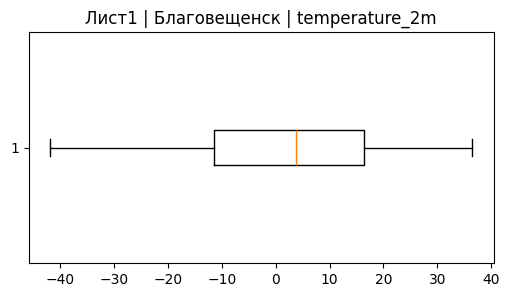

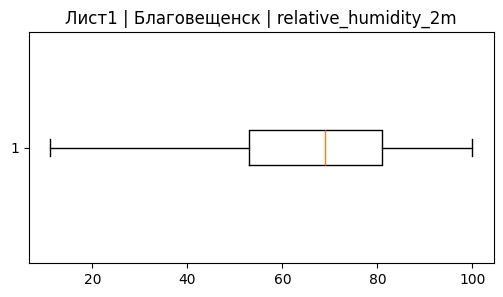

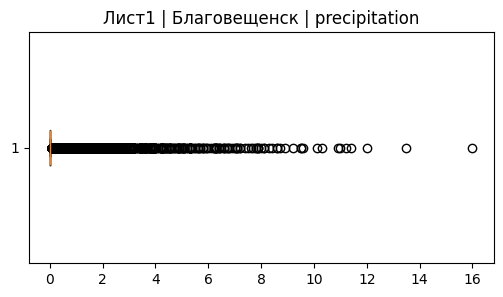

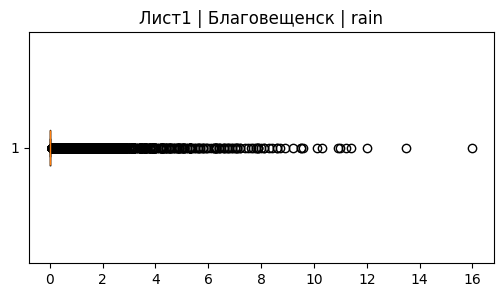

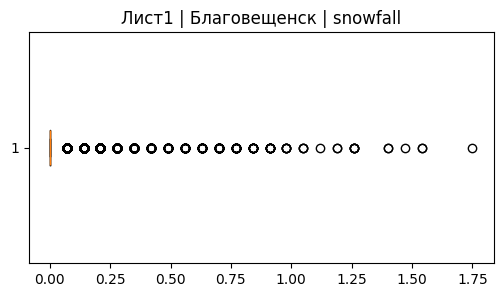

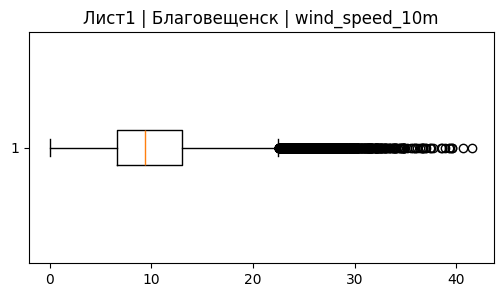

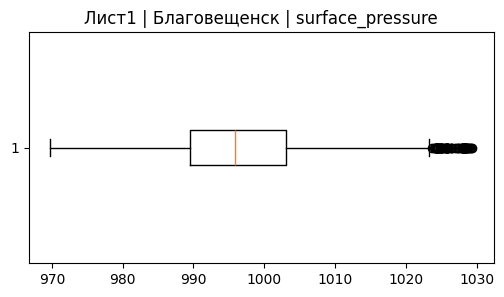

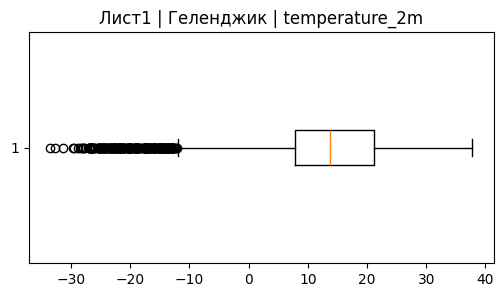

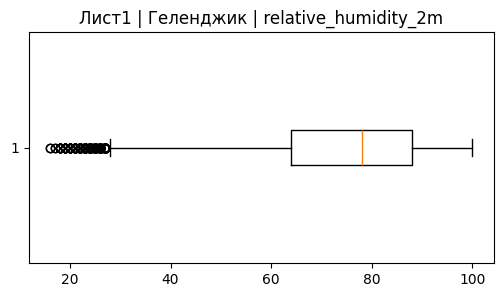

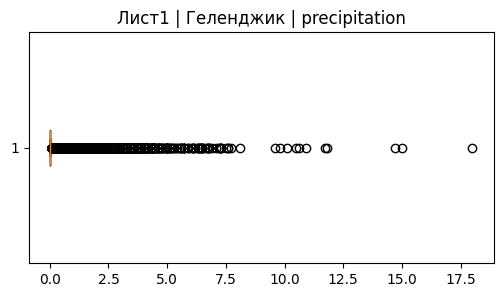

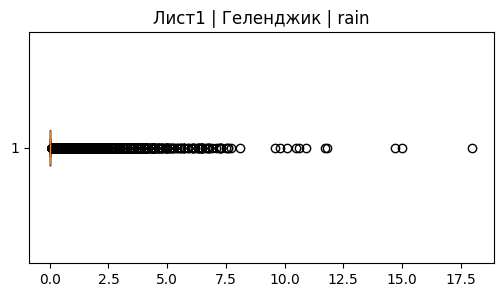

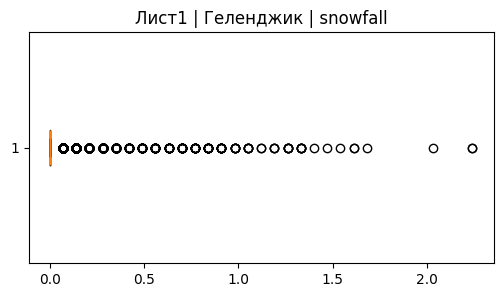

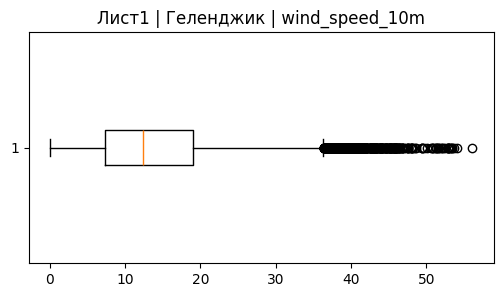

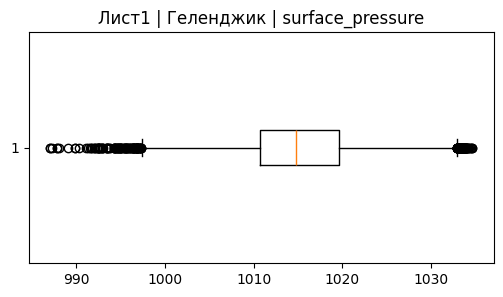

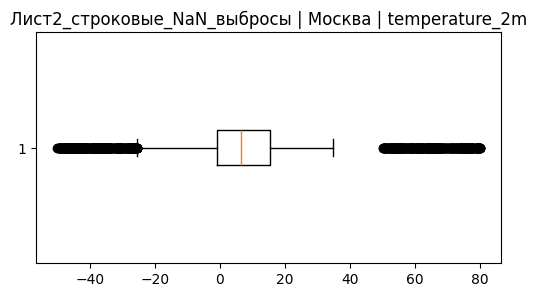

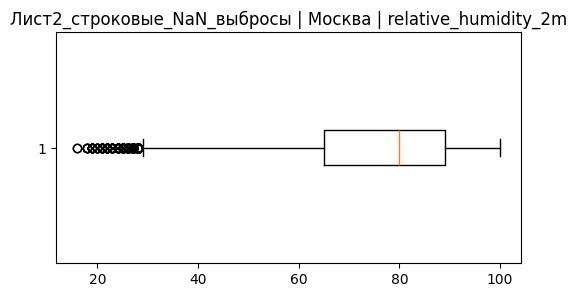

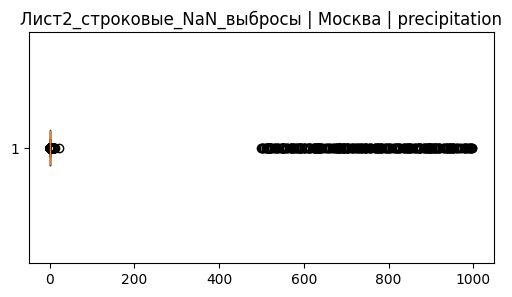

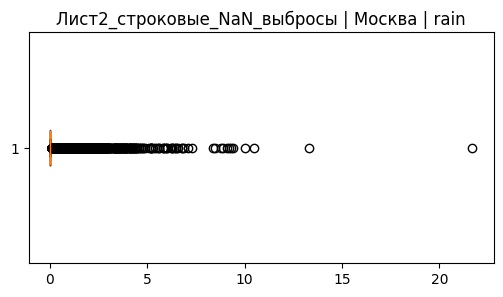

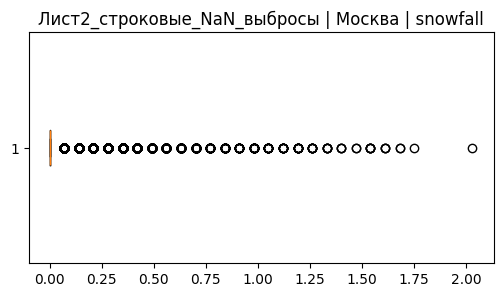

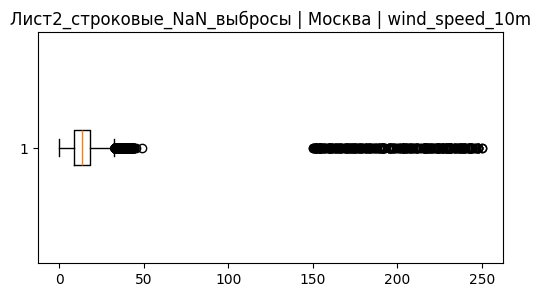

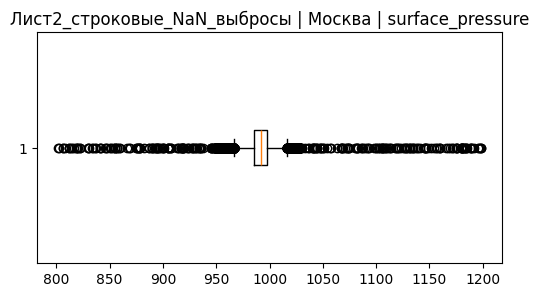

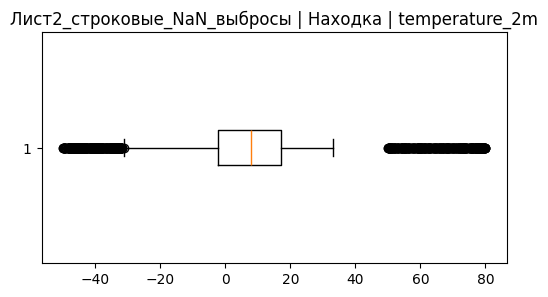

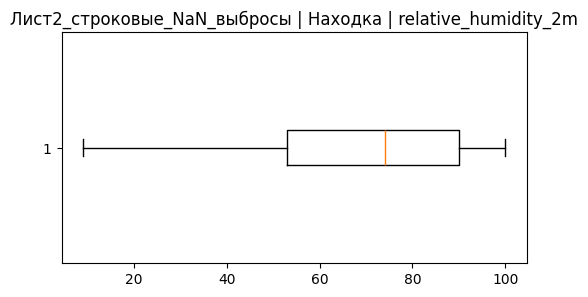

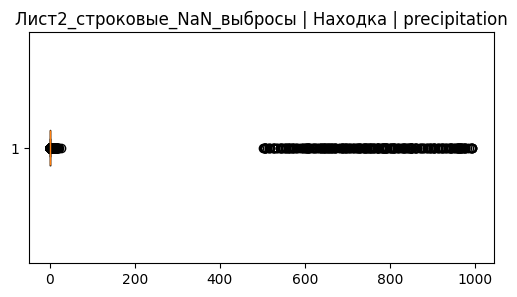

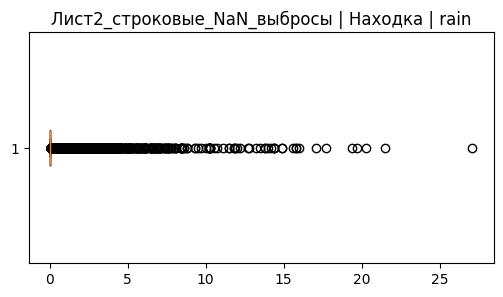

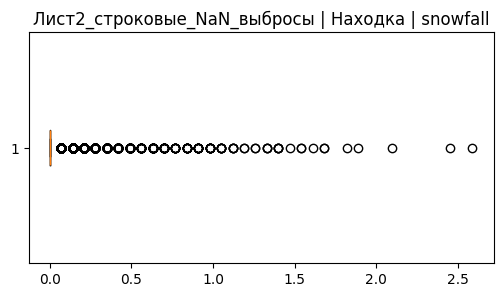

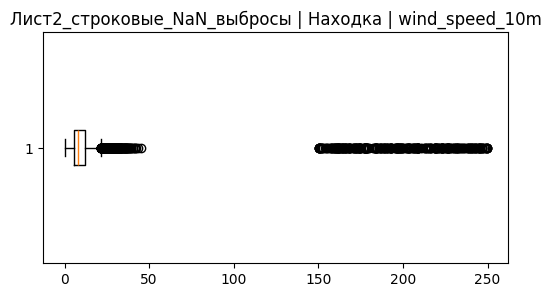

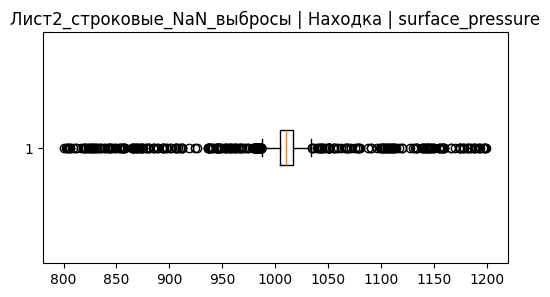

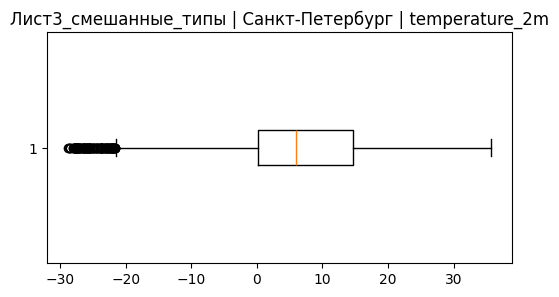

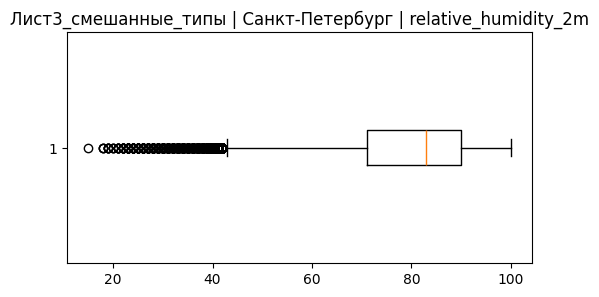

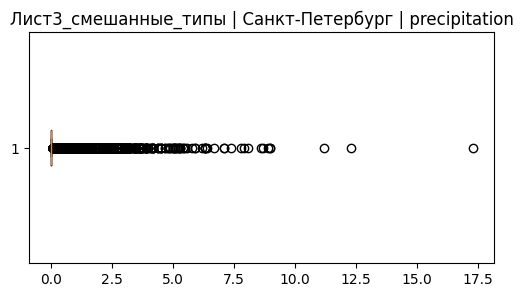

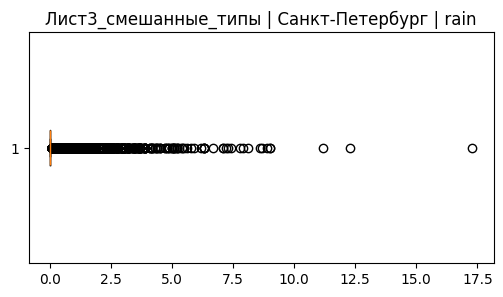

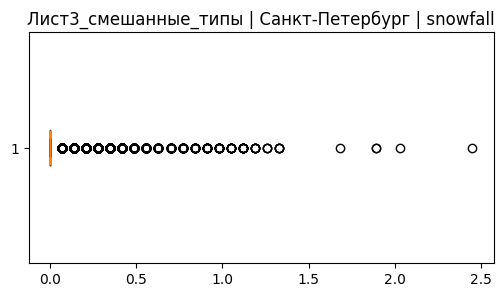

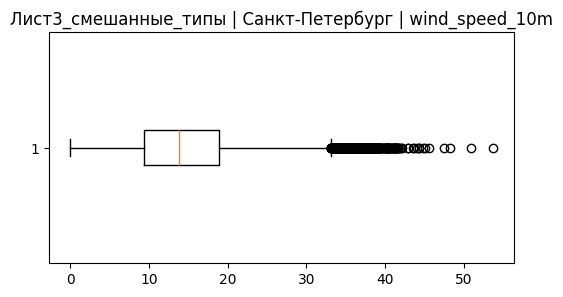

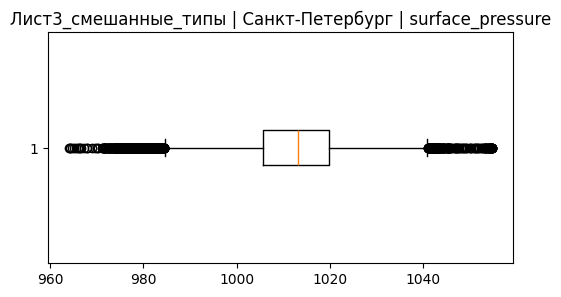

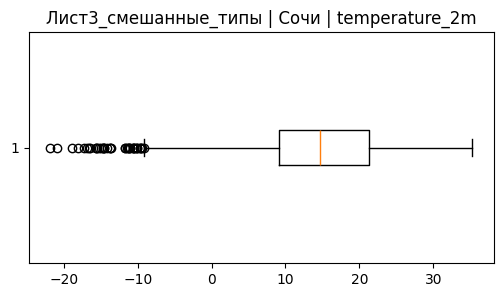

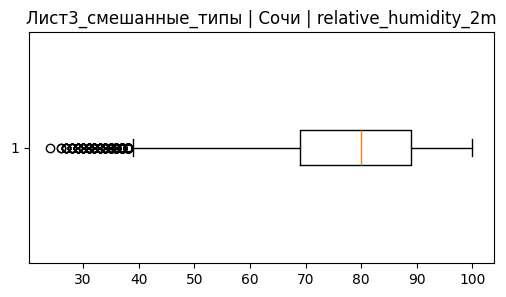

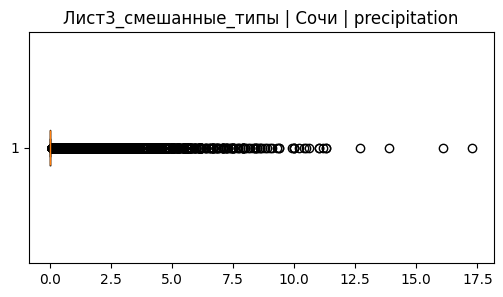

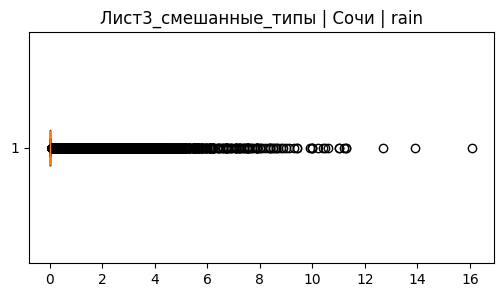

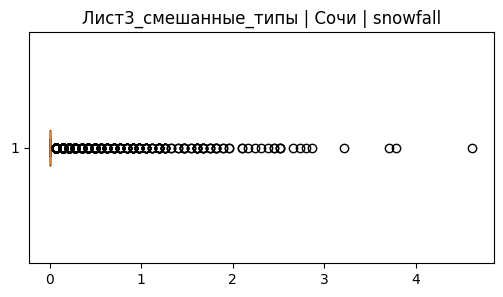

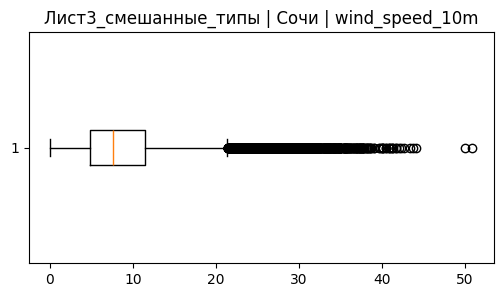

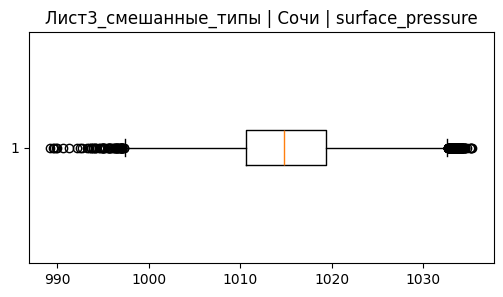

In [15]:
import matplotlib.pyplot as plt

numeric_cols = ["temperature_2m", "relative_humidity_2m", "precipitation", "rain", "snowfall", "wind_speed_10m", "surface_pressure"]

for name, sheet in df.items():
    if sheet.index.name == "ds":

        for city, city_df in sheet.groupby("city"):

            for col in numeric_cols:

                plt.figure(figsize=(6, 3))
                plt.boxplot(city_df[col].dropna(), vert=False)
                plt.title(f"{name} | {city} | {col}")
                plt.show()

После анализа графиков было установлено, что выбросы присутствуют в следующих данных:

- temperature_2m, Москва (меньше -42,2, больше +40)
- precipitation, Москва (больше +200)
- wind_speed_10m, Москва (больше +100)
- surface_pressure, Москва (меньше +900, больше +1100)

- temperature_2m, Находка (меньше -30, больше +40)
- precipitation, Находка (больше +400)
- wind_speed_10m, Находка (больше +100)
- surface_pressure, Находка (меньше +900, больше +1100)

- temperature_2m, Сочи (меньше -13,4)

Обработаем все выбросы в данных с помощью замены на pd.NA и последующей интерполяции.

In [16]:
for name, sheet in df.items():
    if "city" in sheet.columns:
        for city, city_df in sheet.groupby("city"):
            if city == "Москва":
                sheet.loc[(sheet["city"] == city) & ((sheet["temperature_2m"] < -42.2) | (sheet["temperature_2m"] > 40)), "temperature_2m"] = pd.NA
                sheet.loc[(sheet["city"] == city) & (sheet["precipitation"] > 200), "precipitation"] = pd.NA
                sheet.loc[(sheet["city"] == city) & (sheet["wind_speed_10m"] > 100), "wind_speed_10m"] = pd.NA
                sheet.loc[(sheet["city"] == city) & ((sheet["surface_pressure"] < 900) | (sheet["surface_pressure"] > 1100)), "surface_pressure"] = pd.NA
            if city == "Находка":
                sheet.loc[(sheet["city"] == city) & ((sheet["temperature_2m"] < -30) | (sheet["temperature_2m"] > 40)), "temperature_2m"] = pd.NA
                sheet.loc[(sheet["city"] == city) & (sheet["precipitation"] > 400), "precipitation"] = pd.NA
                sheet.loc[(sheet["city"] == city) & (sheet["wind_speed_10m"] > 100), "wind_speed_10m"] = pd.NA
                sheet.loc[(sheet["city"] == city) & ((sheet["surface_pressure"] < 900) | (sheet["surface_pressure"] > 1100)), "surface_pressure"] = pd.NA
            if city == "Сочи":
                sheet.loc[(sheet["city"] == city) & (sheet["temperature_2m"] < -13.4), "temperature_2m"] = pd.NA

        df[name] = sheet

numeric_cols = ["temperature_2m", "relative_humidity_2m", "precipitation", "rain", "snowfall", "weathercode", "wind_speed_10m", "surface_pressure"]

for name, sheet in df.items():
    if sheet.index.name == "ds":
        existing_num = [col for col in numeric_cols if col in sheet.columns]
        sheet[existing_num] = sheet[existing_num].interpolate(method="time", limit_direction="both")
        df[name] = sheet


Построим графики чтобы посмотреть, не осталось ли выбросов.

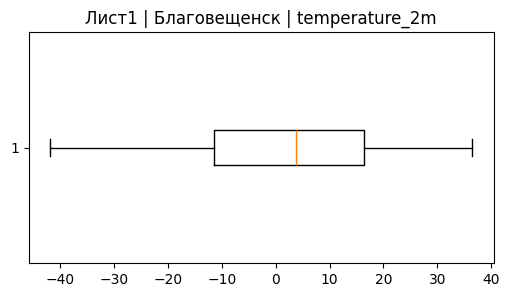

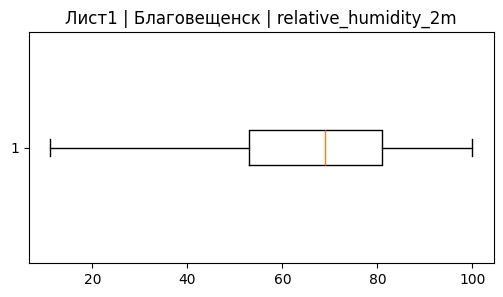

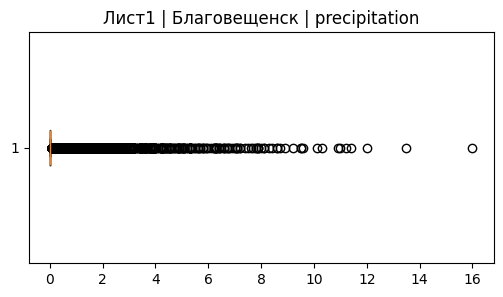

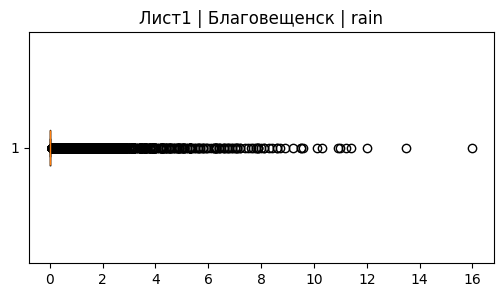

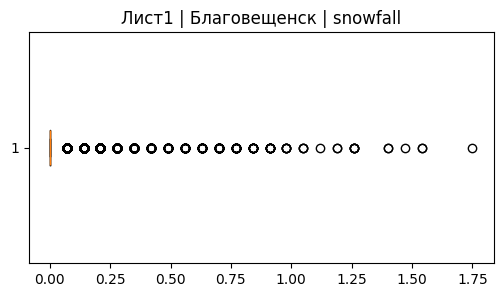

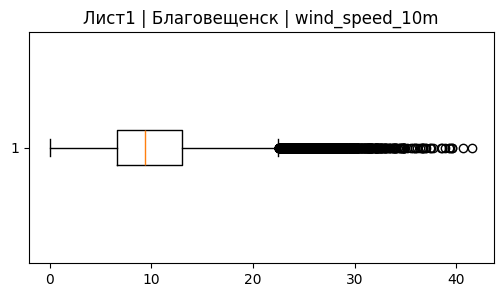

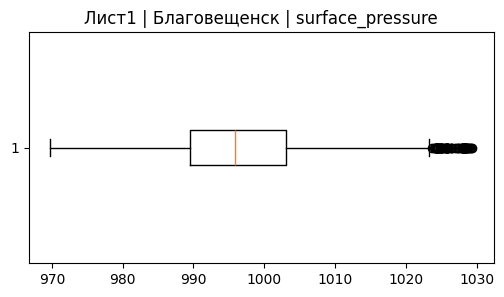

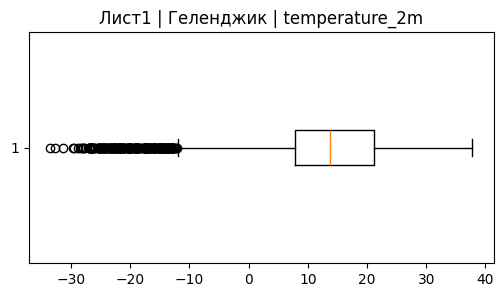

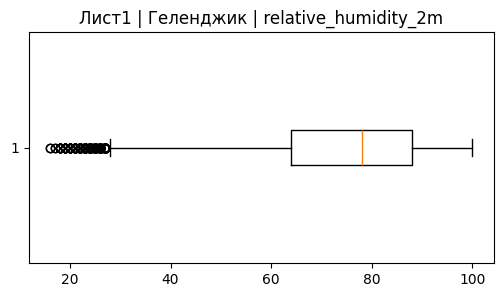

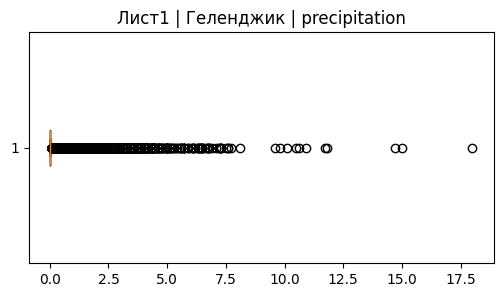

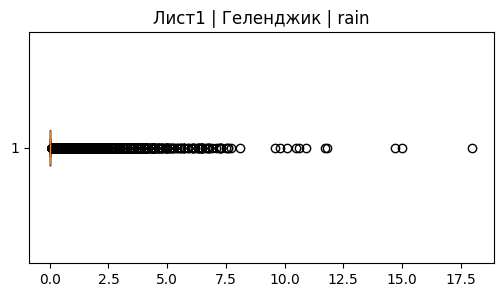

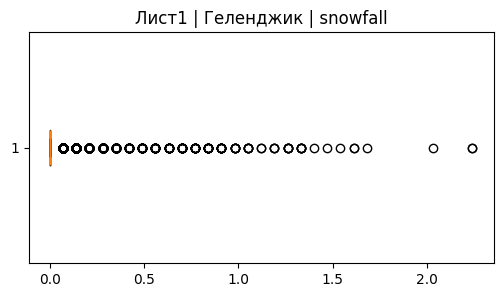

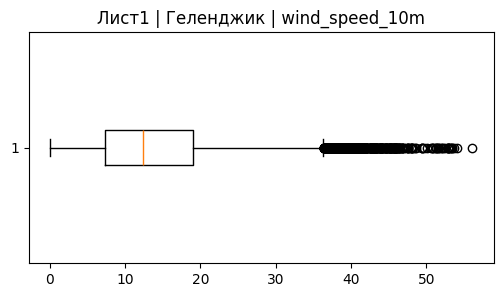

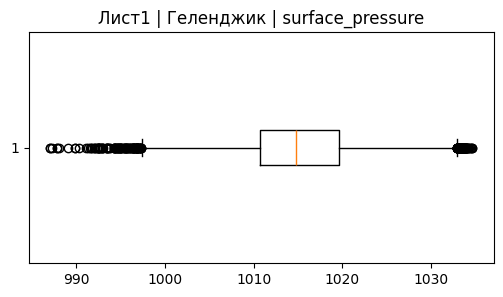

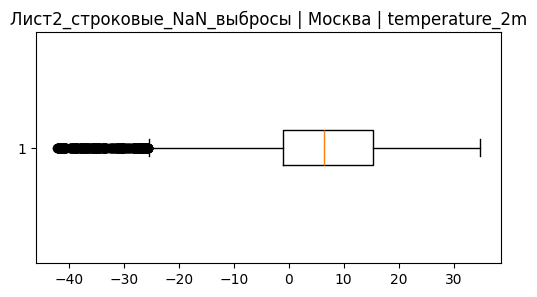

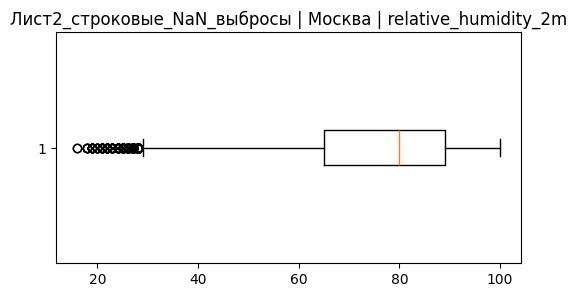

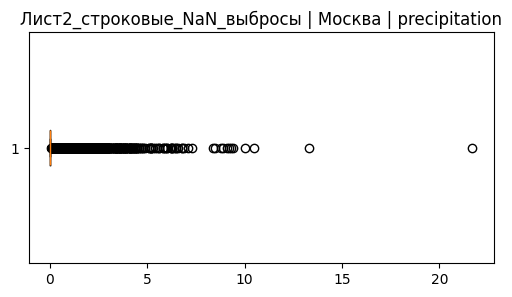

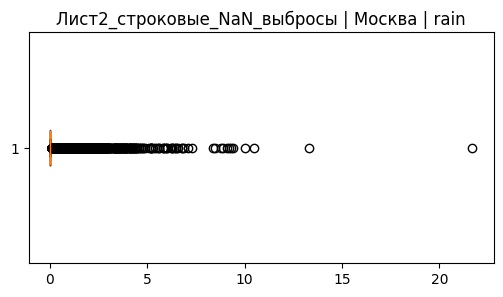

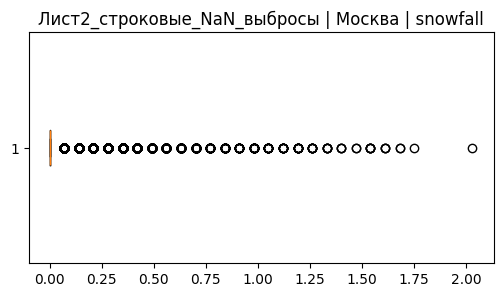

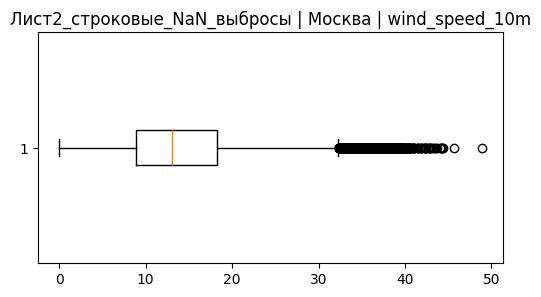

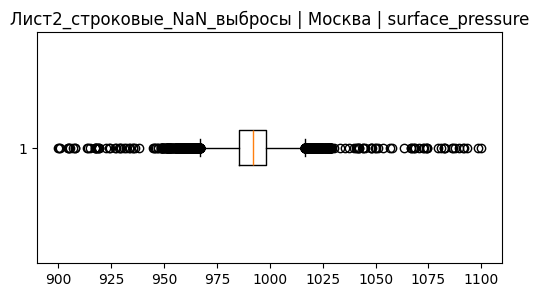

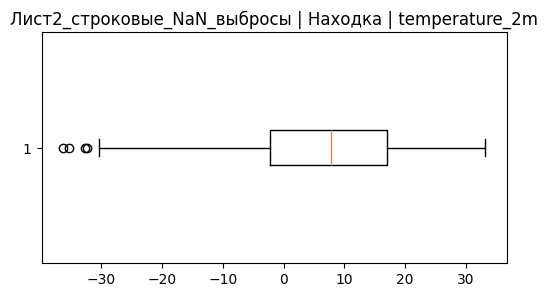

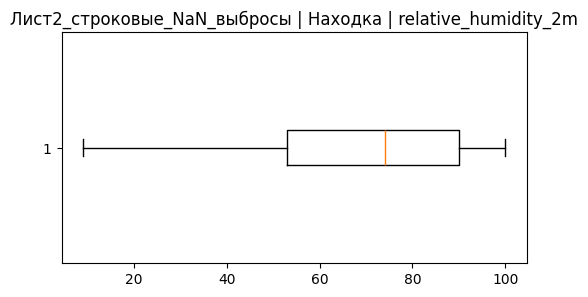

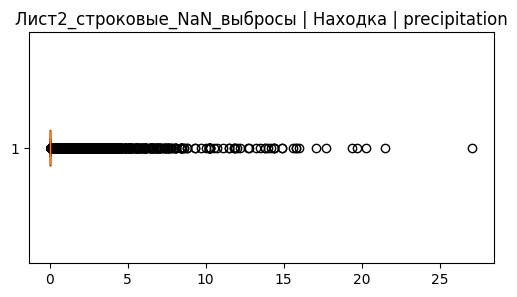

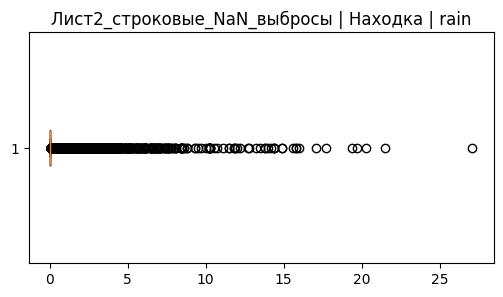

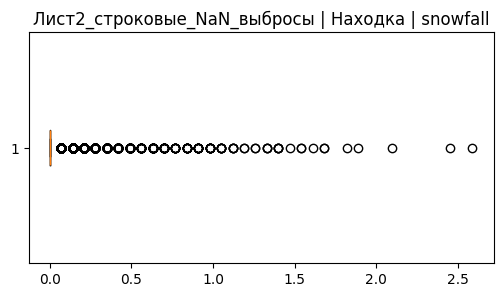

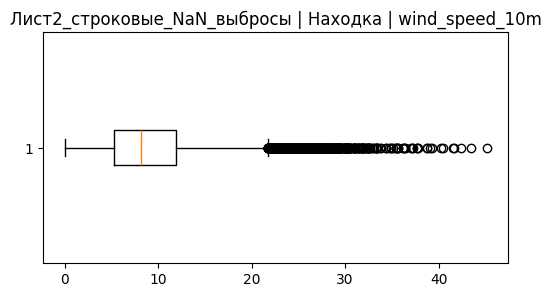

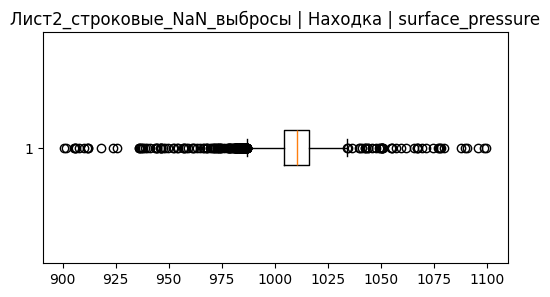

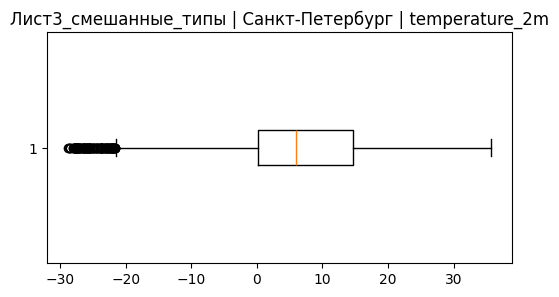

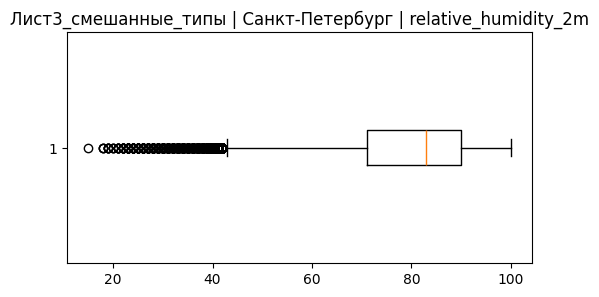

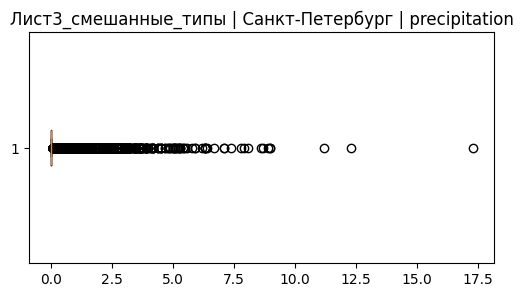

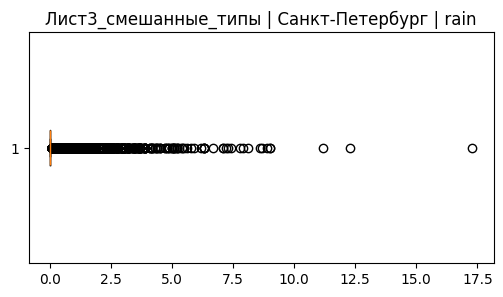

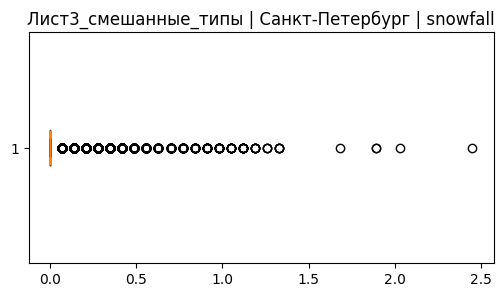

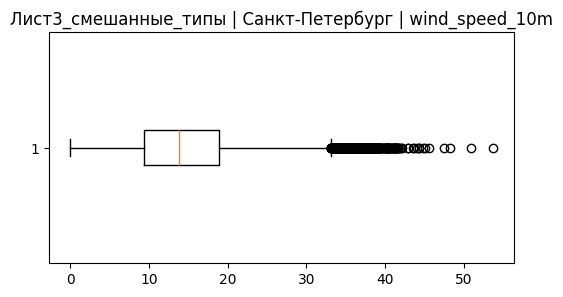

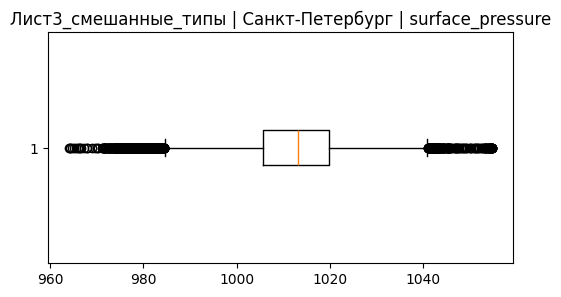

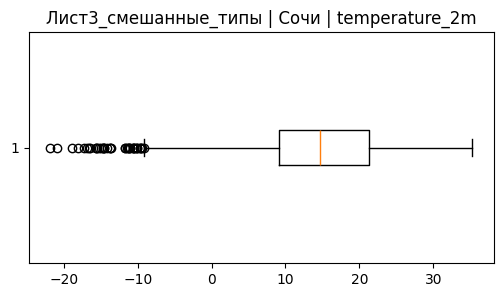

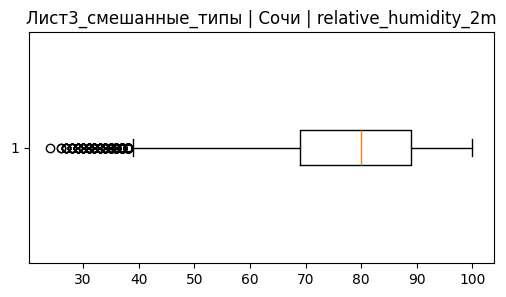

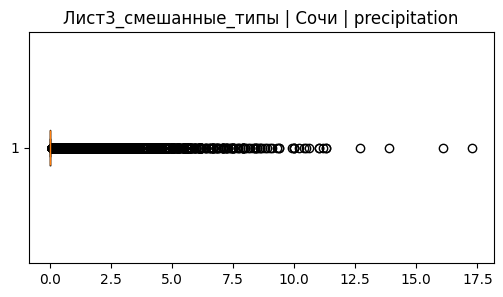

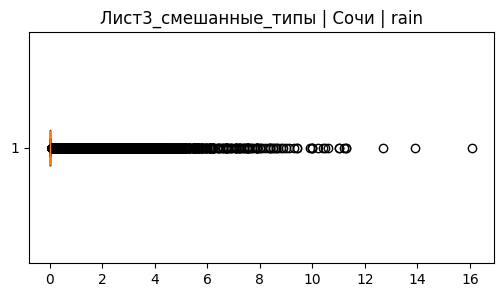

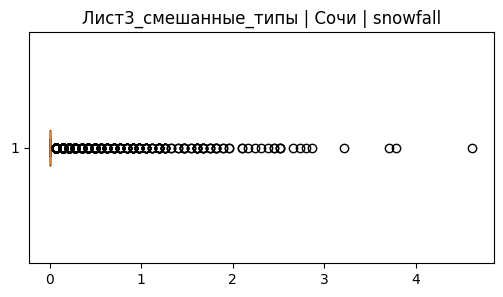

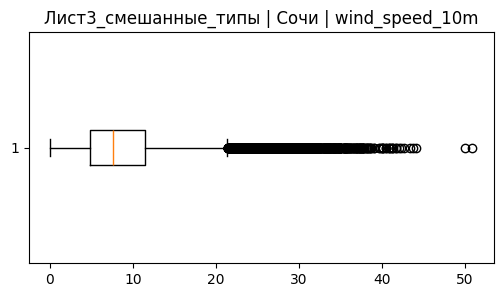

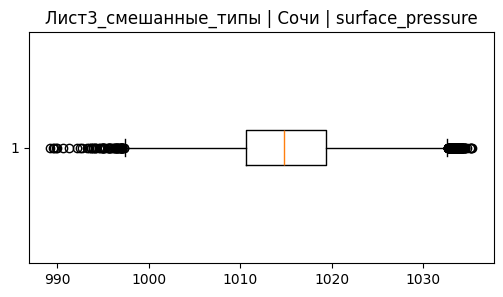

In [17]:
import matplotlib.pyplot as plt

numeric_cols = ["temperature_2m", "relative_humidity_2m", "precipitation", "rain", "snowfall", "wind_speed_10m", "surface_pressure"]

for name, sheet in df.items():
    if sheet.index.name == "ds":

        for city, city_df in sheet.groupby("city"):

            for col in numeric_cols:

                plt.figure(figsize=(6, 3))
                plt.boxplot(city_df[col].dropna(), vert=False)
                plt.title(f"{name} | {city} | {col}")
                plt.show()

Как видно из новых графиков, выбросов данных больше нет, поэтому можно начинать проводить анализ временного ряда.

# Анализ временного ряда

По условию лабораторной работы, таргет-признак временного ряда – температура воздуха, поэтому построим визуализацию значений нашего таргет-признака для каждого города: 

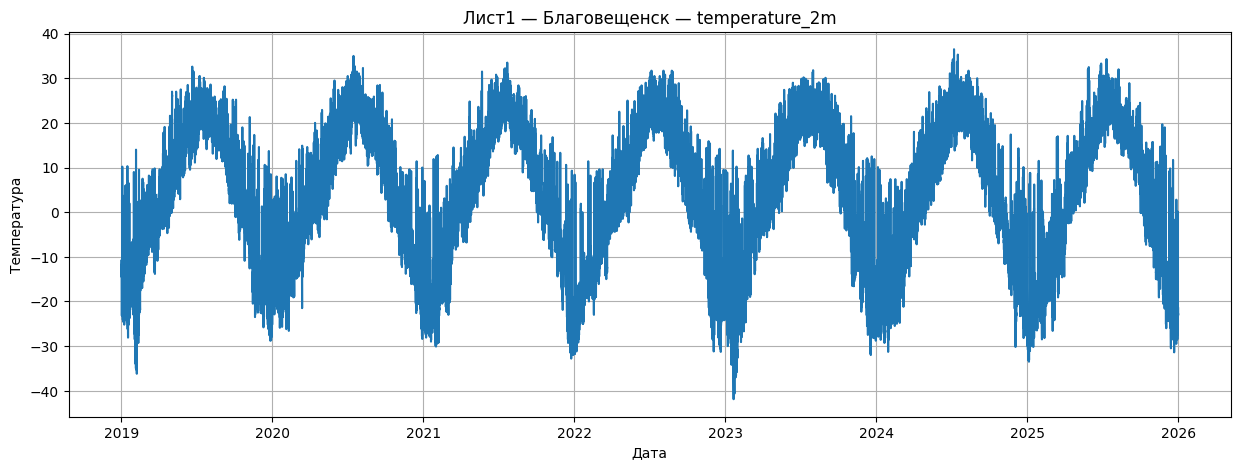

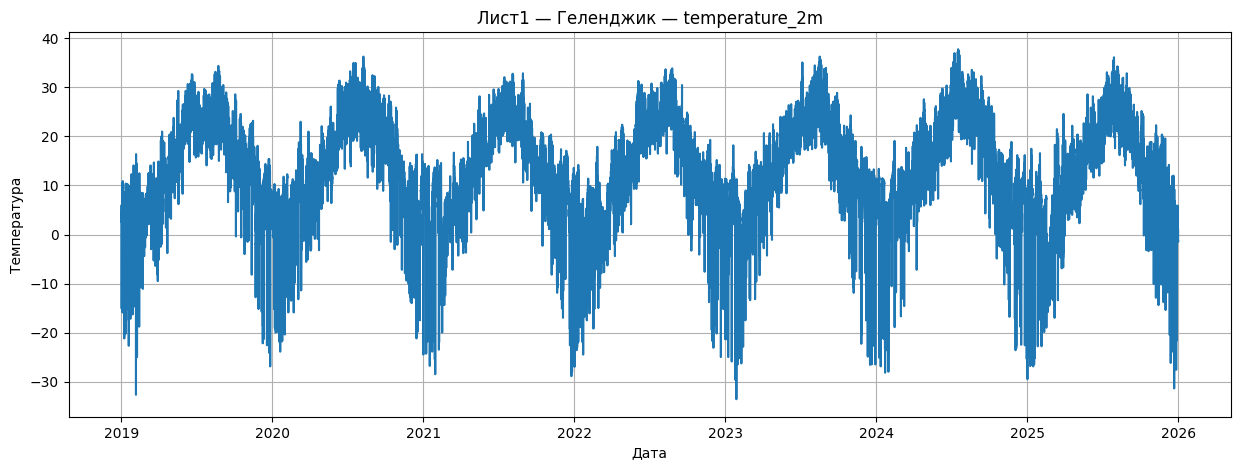

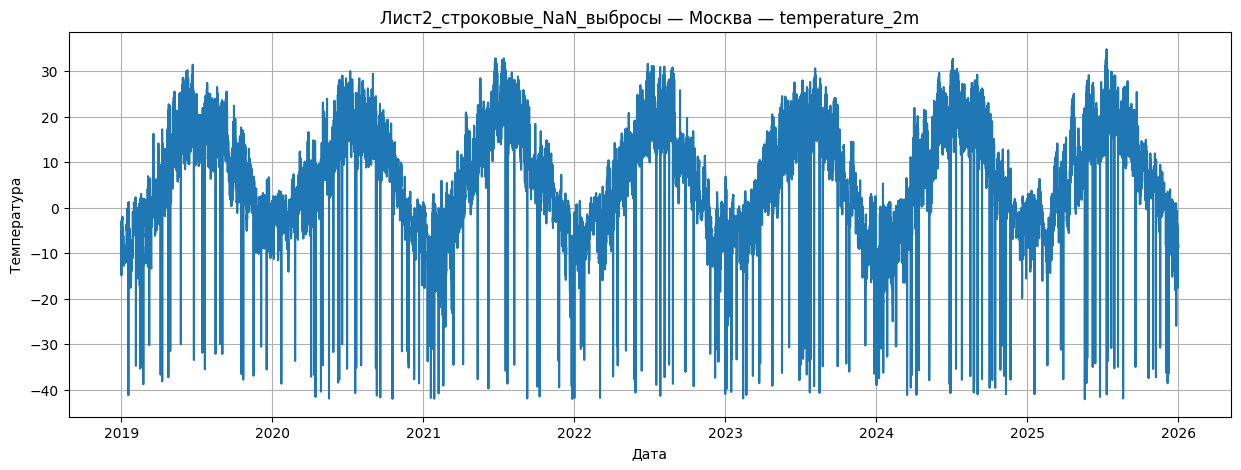

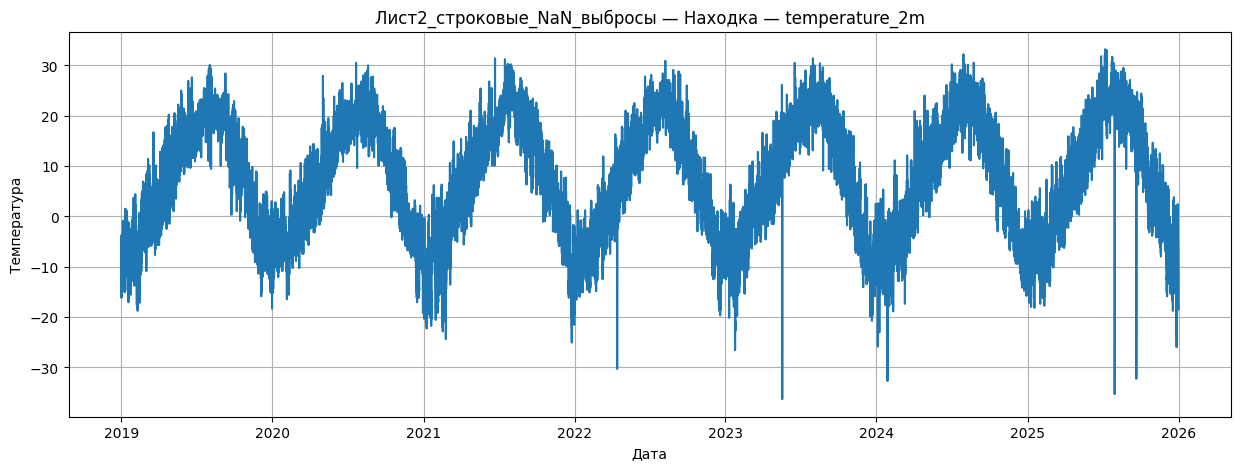

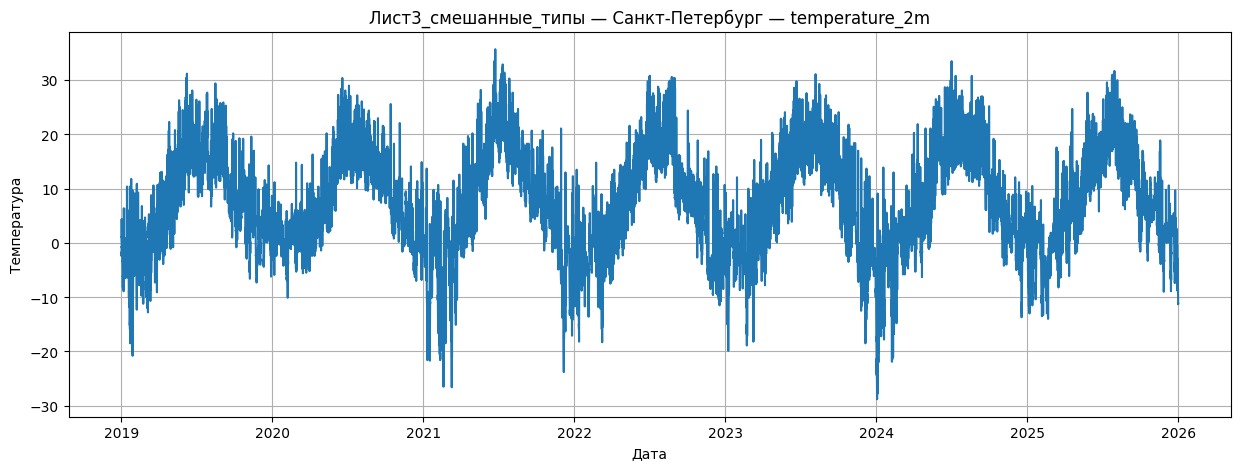

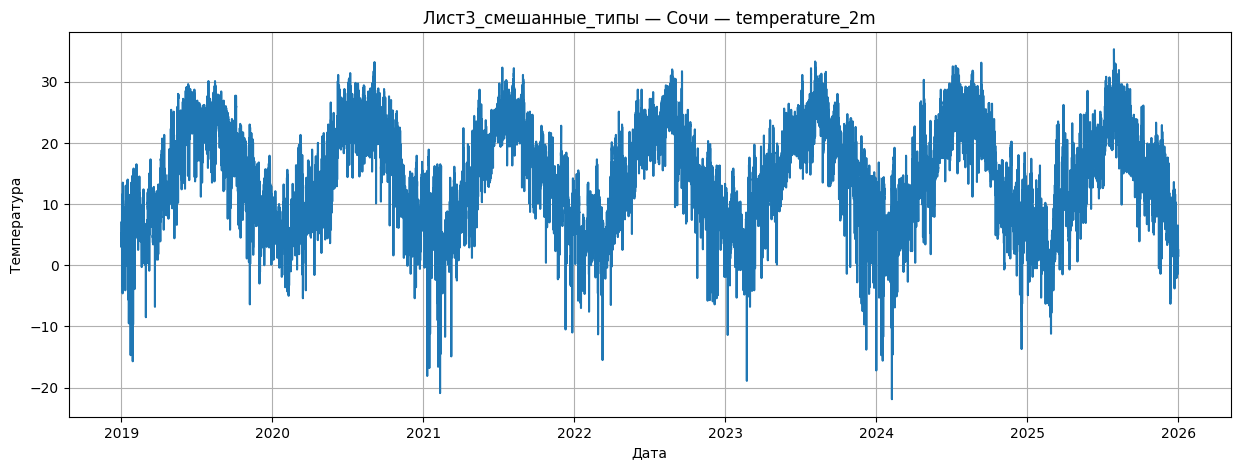

In [18]:
import matplotlib.pyplot as plt
for name, sheet in df.items():
    if sheet.index.name == "ds":
        for city, city_df in sheet.groupby("city"):
            plt.figure(figsize=(15, 5))
            plt.plot(city_df.index, city_df["temperature_2m"])
            plt.title(f"{name} — {city} — temperature_2m")
            plt.xlabel("Дата")
            plt.ylabel("Температура")
            plt.grid()
            plt.show()

Проверим наш временной ряд на стационарность с помощью теста Дики-Фуллера:

In [19]:
from statsmodels.tsa.stattools import adfuller

for name, sheet in df.items():
    if sheet.index.name == "ds":
        for city, city_df in sheet.groupby("city"):
            series = city_df["temperature_2m"].dropna()
            result = adfuller(series)
            print(f"\n{name} | {city}")
            print("ADF Statistic:", result[0])
            print("p-value:", result[1])
            print("Critical Values:")
            for key, value in result[4].items():
                print(f"{key}: {value}")


Лист1 | Благовещенск
ADF Statistic: -4.045441582978291
p-value: 0.001190393033429011
Critical Values:
1%: -3.4304566692844776
5%: -2.861587145824668
10%: -2.566795094129848

Лист1 | Геленджик
ADF Statistic: -7.075497422788065
p-value: 4.813977620695832e-10
Critical Values:
1%: -3.430456667544513
5%: -2.8615871450556503
10%: -2.5667950937205233

Лист2_строковые_NaN_выбросы | Москва
ADF Statistic: -6.793137344157534
p-value: 2.337008107810668e-09
Critical Values:
1%: -3.4304566692844776
5%: -2.861587145824668
10%: -2.566795094129848

Лист2_строковые_NaN_выбросы | Находка
ADF Statistic: -5.067236267552648
p-value: 1.6309088910920028e-05
Critical Values:
1%: -3.4304567006135502
5%: -2.861587159671282
10%: -2.5667951014999764

Лист3_смешанные_типы | Санкт-Петербург
ADF Statistic: -6.420053850517736
p-value: 1.8008596014965116e-08
Critical Values:
1%: -3.4304566692844776
5%: -2.861587145824668
10%: -2.566795094129848

Лист3_смешанные_типы | Сочи
ADF Statistic: -6.630750273818276
p-value: 5.

Для всех городов получены значения p-value < 0.05, что позволяет отвергнуть нулевую гипотезу о наличии единичного корня и сделать вывод о стационарности рядов по критерию ADF.

Декомпозируем временной ряд на тренд, сезонность и остатки:

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

from pylab import rcParams
rcParams['figure.figsize'] = 14, 10

for name, sheet in df.items():
    if sheet.index.name == "ds":
        for city, city_df in sheet.groupby("city"):
            decompose = seasonal_decompose(city_df["temperature_2m"], period=90*24)
            fig = decompose.plot()
            fig.suptitle(f"{name} | {city}", fontsize=16,y=1.02)
            fig.tight_layout()
            plt.show()

NameError: name 'df' is not defined

В результате декомпозиции временных рядов температуры данные были разделены на три основные компоненты: тренд (долгосрочное изменение температуры), сезонность (повторяющиеся годовые колебания) и остатки (случайные отклонения и выбросы). Для анализа использовался параметр period = 365 × 24, соответствующий годовому циклу для почасовых данных.

Во всех городах наблюдается ярко выраженная годовая сезонность: зимой температура снижается, летом повышается. Seasonal-компонента имеет форму повторяющейся волны, отражающей смену времён года.

Наиболее сильные сезонные колебания наблюдаются в Благовещенске — это связано с резко континентальным климатом. В Геленджике и Сочи сезонность выражена слабее, температуры изменяются более плавно благодаря мягкому морскому климату. Москва и Санкт-Петербург занимают промежуточное положение: сезонность хорошо заметна, но амплитуда колебаний ниже, чем в Благовещенске. В Находке температурный режим также достаточно стабильный, без резких скачков.

Трендовая компонента показывает долгосрочные изменения средней температуры. В большинстве городов тренд изменяется плавно, без резких скачков, однако в Москве и Благовещенске заметны более выраженные изменения среднего температурного уровня в разные периоды наблюдений.

Residual-компонента отражает случайные отклонения, шум и аномалии. Наибольшее количество выбросов наблюдается в Москве, что связано с исходными пропусками и экстремальными значениями в данных. В Сочи и Геленджике остаточные отклонения значительно меньше, что говорит о более стабильном климате.

В целом декомпозиция выделила климатические особенности каждого города и показала различия между континентальным и морским типами климата.

После анализа тренда и сезонности проведём спектральный анализ временных рядов температуры методом быстрого преобразования Фурье.

Спектральный анализ позволяет определить, какие периодические колебания присутствуют в данных и насколько они выражены. В отличие от обычного временного ряда, где температура рассматривается как функция времени, FFT переводит данные в частотную область и показывает доминирующие циклы.

Для температурных данных это позволяет выявить:

- суточную периодичность;

- сезонные годовые колебания;

- дополнительные циклы и шумовые компоненты.

На данном этапе проведём анализ временного ряда температуры для города Москва.

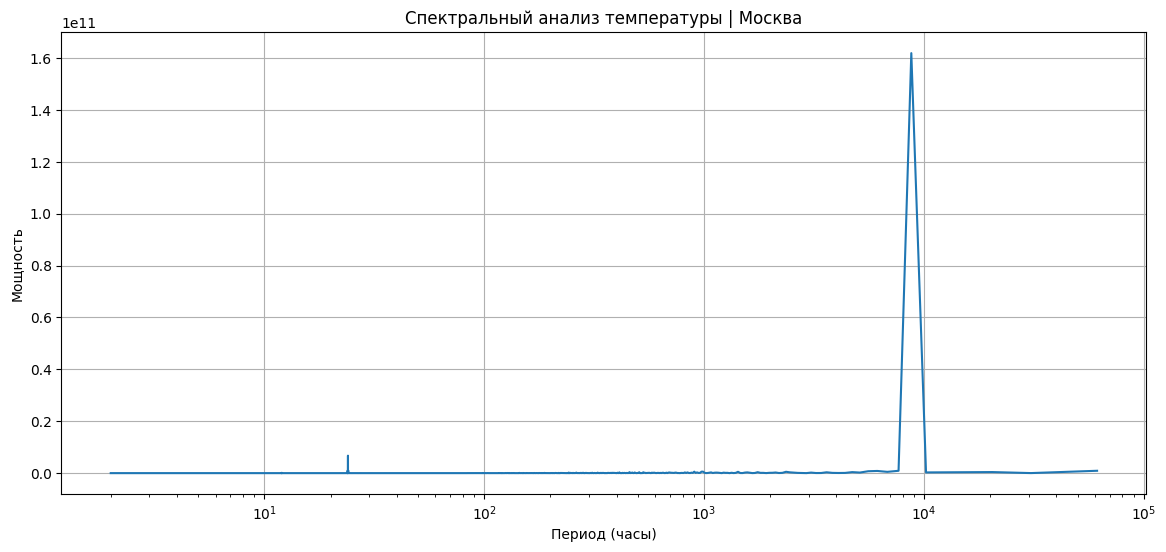

In [31]:
import numpy as np
import matplotlib.pyplot as plt

city_df = df["Лист2_строковые_NaN_выбросы"]
city_df = city_df[city_df["city"] == "Москва"]

signal = city_df["temperature_2m"].dropna().values

n = len(signal)

fft_vals = np.fft.rfft(signal)
fft_freqs = np.fft.rfftfreq(n, d=1)

power = np.abs(fft_vals) ** 2

periods = 1 / fft_freqs[1:]

plt.figure(figsize=(14, 6))

plt.plot(periods, power[1:])

plt.xscale("log")

plt.xlabel("Период (часы)")
plt.ylabel("Мощность")
plt.title("Спектральный анализ температуры | Москва")

plt.grid()

plt.show()

Спектральный анализ временного ряда температуры Москвы показал наличие ярко выраженной годовой сезонности. На спектре наблюдается основной пик с периодом около 8760 часов (365 × 24), что соответствует годовому циклу изменения температуры.

Также присутствует менее выраженный пик около 24 часов, отражающий суточные колебания температуры, связанные со сменой дня и ночи.

Доминирование годовой периодичности свидетельствует о сильном влиянии сезонных климатических изменений на температурный режим Москвы. Остальные частоты имеют значительно меньшую мощность и соответствуют менее выраженным или случайным колебаниям.

Проведем анализ для города Находка:

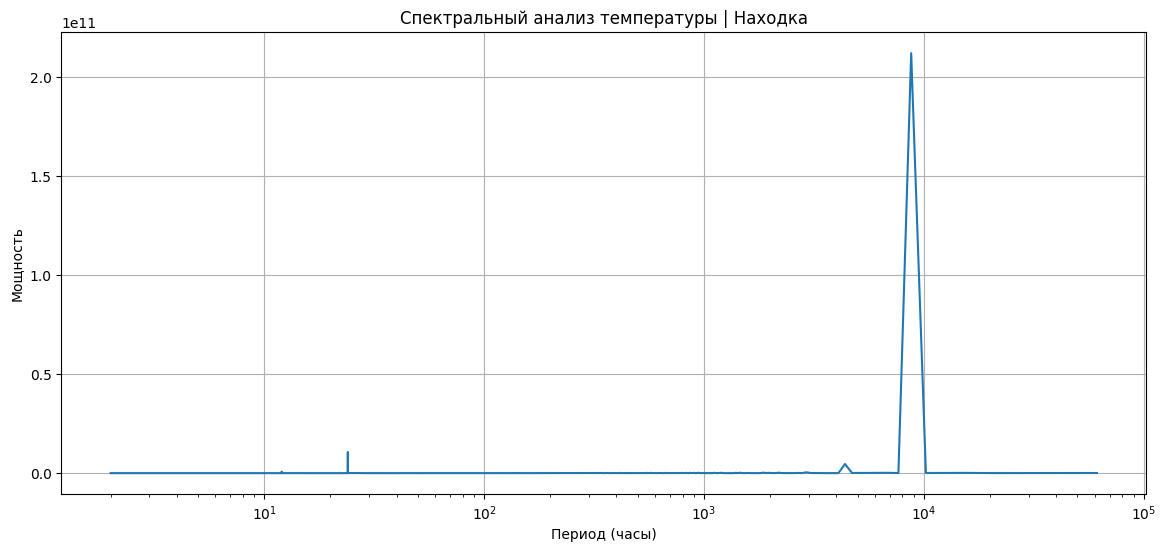

In [32]:
import numpy as np
import matplotlib.pyplot as plt

city_df = df["Лист2_строковые_NaN_выбросы"]
city_df = city_df[city_df["city"] == "Находка"]

signal = city_df["temperature_2m"].dropna().values

n = len(signal)

fft_vals = np.fft.rfft(signal)
fft_freqs = np.fft.rfftfreq(n, d=1)

power = np.abs(fft_vals) ** 2

periods = 1 / fft_freqs[1:]

plt.figure(figsize=(14, 6))

plt.plot(periods, power[1:])

plt.xscale("log")

plt.xlabel("Период (часы)")
plt.ylabel("Мощность")
plt.title("Спектральный анализ температуры | Находка")

plt.grid()

plt.show()

Спектральный анализ временного ряда температуры Находки показал наличие ярко выраженной годовой сезонности. На спектре наблюдается основной пик с периодом около 8760 часов, что соответствует годовому циклу изменения температуры.

Также присутствует менее выраженная суточная периодичность с периодом около 24 часов, отражающая изменение температуры в течение суток.

По сравнению с Москвой спектр Находки выглядит более сглаженным, а дополнительные пики выражены слабее. Это свидетельствует о более стабильном температурном режиме и меньшем количестве резких колебаний. Основное влияние на температурный ряд оказывает сезонная смена времён года.

Проведем спектральный анализ для города Благовещенск:

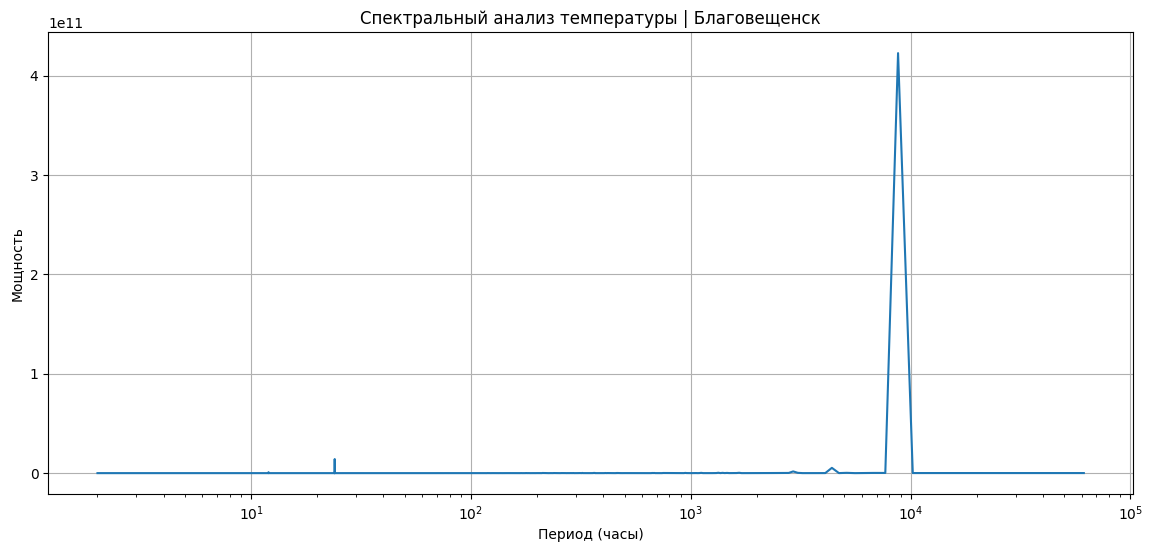

In [33]:
import numpy as np
import matplotlib.pyplot as plt

city_df = df["Лист1"]
city_df = city_df[city_df["city"] == "Благовещенск"]

signal = city_df["temperature_2m"].dropna().values

n = len(signal)

fft_vals = np.fft.rfft(signal)
fft_freqs = np.fft.rfftfreq(n, d=1)

power = np.abs(fft_vals) ** 2

periods = 1 / fft_freqs[1:]

plt.figure(figsize=(14, 6))

plt.plot(periods, power[1:])

plt.xscale("log")

plt.xlabel("Период (часы)")
plt.ylabel("Мощность")
plt.title("Спектральный анализ температуры | Благовещенск")

plt.grid()

plt.show()

Спектральный анализ временного ряда температуры Благовещенска показал очень сильную годовую сезонность. На спектре наблюдается наиболее высокий пик среди рассмотренных городов с периодом около 8760 часов, что соответствует годовому циклу температуры.

Также заметен суточный цикл с периодом около 24 часов, однако его мощность значительно ниже по сравнению с годовой периодичностью.

Высокая мощность годового пика указывает на резко выраженную смену времён года и сильные сезонные перепады температуры. Это характерно для резко континентального климата Благовещенска, где наблюдаются очень холодные зимы и тёплое лето. Дополнительные колебания и шумовые компоненты выражены слабо по сравнению с основной сезонностью.

Проведем спектральный анализ для города Геленджик:

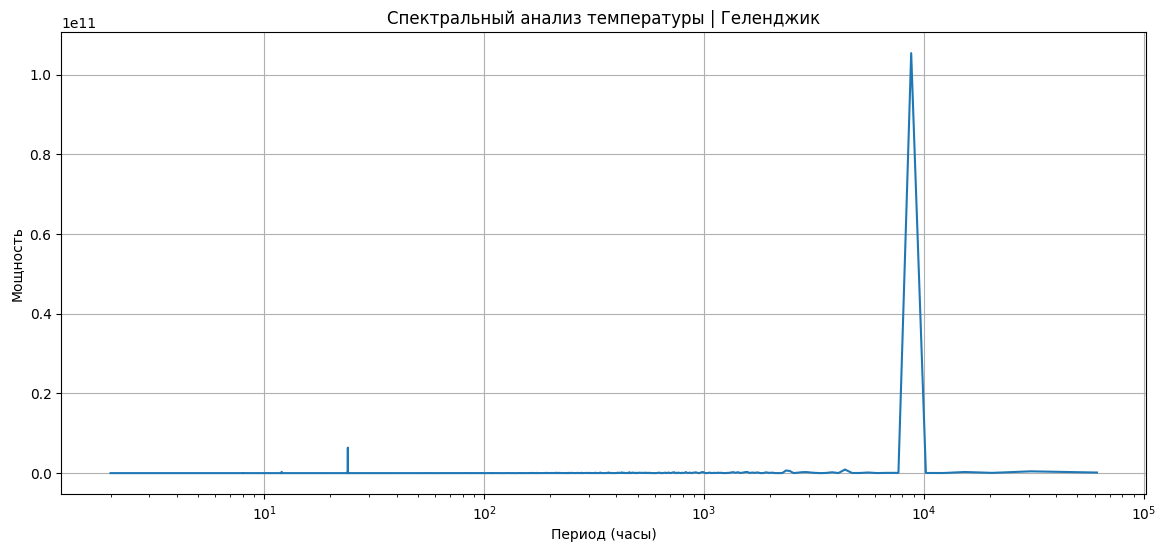

In [34]:
import numpy as np
import matplotlib.pyplot as plt

city_df = df["Лист1"]
city_df = city_df[city_df["city"] == "Геленджик"]

signal = city_df["temperature_2m"].dropna().values

n = len(signal)

fft_vals = np.fft.rfft(signal)
fft_freqs = np.fft.rfftfreq(n, d=1)

power = np.abs(fft_vals) ** 2

periods = 1 / fft_freqs[1:]

plt.figure(figsize=(14, 6))

plt.plot(periods, power[1:])

plt.xscale("log")

plt.xlabel("Период (часы)")
plt.ylabel("Мощность")
plt.title("Спектральный анализ температуры | Геленджик")

plt.grid()

plt.show()

Спектральный анализ временного ряда температуры Геленджика показал наличие выраженной годовой сезонности. Основной пик спектра соответствует периоду около 8760 часов, что отражает годовой цикл изменения температуры.

Также наблюдается суточная периодичность с периодом около 24 часов, однако её мощность значительно ниже годовой сезонности.

По сравнению с Благовещенском и Москвой мощность годового пика ниже, что связано с более мягким морским климатом Геленджика и меньшей амплитудой сезонных температурных колебаний. Температурный режим города является более стабильным, а дополнительные шумовые компоненты выражены слабо.

Проведем спектральный анализ для города Санкт-Петербурга:

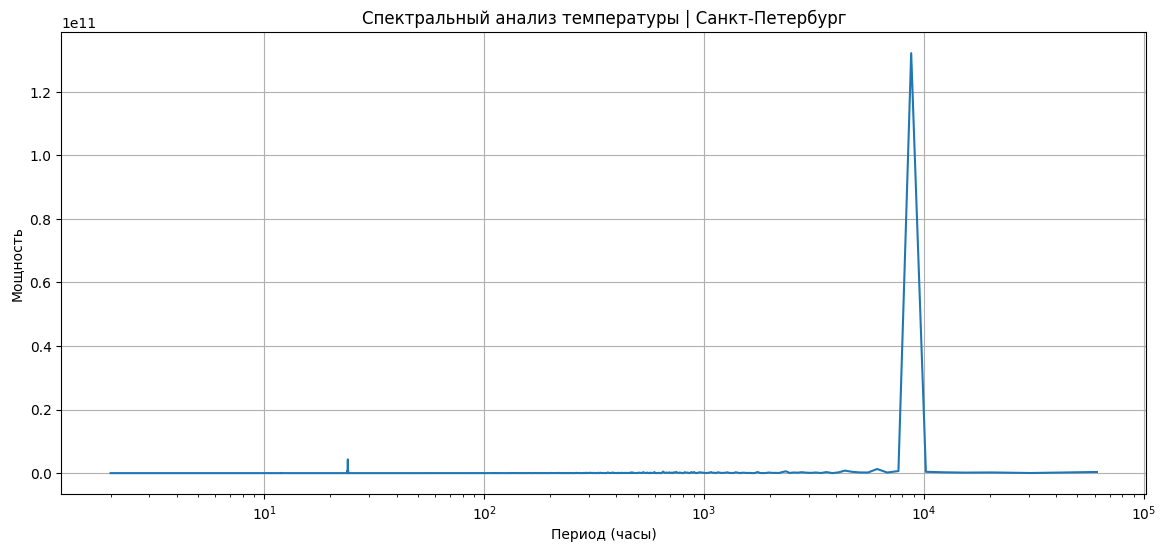

In [35]:
import numpy as np
import matplotlib.pyplot as plt

city_df = df["Лист3_смешанные_типы"]
city_df = city_df[city_df["city"] == "Санкт-Петербург"]

signal = city_df["temperature_2m"].dropna().values

n = len(signal)

fft_vals = np.fft.rfft(signal)
fft_freqs = np.fft.rfftfreq(n, d=1)

power = np.abs(fft_vals) ** 2

periods = 1 / fft_freqs[1:]

plt.figure(figsize=(14, 6))

plt.plot(periods, power[1:])

plt.xscale("log")

plt.xlabel("Период (часы)")
plt.ylabel("Мощность")
plt.title("Спектральный анализ температуры | Санкт-Петербург")

plt.grid()

plt.show()

Спектральный анализ временного ряда температуры Санкт-Петербурга показал наличие выраженной годовой сезонности. Основной пик спектра наблюдается при периоде около 8760 часов, что соответствует годовому циклу изменения температуры.

Также присутствует менее выраженная суточная периодичность с периодом около 24 часов, связанная с изменением температуры в течение суток.

Мощность годового пика ниже, чем в Благовещенске, но выше, чем в Геленджике, что указывает на умеренно выраженные сезонные колебания температуры. Климат Санкт-Петербурга менее контрастный по сравнению с резко континентальными регионами, однако сезонная смена температур остаётся хорошо выраженной. Дополнительные частоты и шумовые колебания имеют небольшую мощность.

Проведем спектральный анализ для города Сочи:

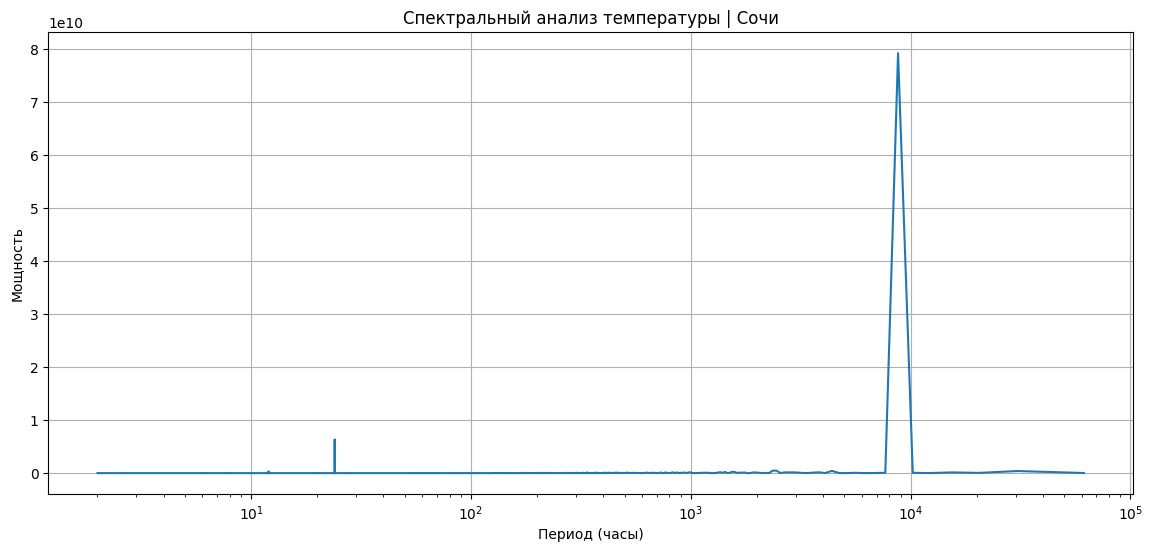

In [36]:
import numpy as np
import matplotlib.pyplot as plt

city_df = df["Лист3_смешанные_типы"]
city_df = city_df[city_df["city"] == "Сочи"]

signal = city_df["temperature_2m"].dropna().values

n = len(signal)

fft_vals = np.fft.rfft(signal)
fft_freqs = np.fft.rfftfreq(n, d=1)

power = np.abs(fft_vals) ** 2

periods = 1 / fft_freqs[1:]

plt.figure(figsize=(14, 6))

plt.plot(periods, power[1:])

plt.xscale("log")

plt.xlabel("Период (часы)")
plt.ylabel("Мощность")
plt.title("Спектральный анализ температуры | Сочи")

plt.grid()

plt.show()

Спектральный анализ временного ряда температуры Сочи показал наличие выраженной годовой сезонности. На спектре наблюдается основной пик с периодом около 8760 часов, соответствующий годовому циклу изменения температуры.

Также присутствует менее выраженная суточная периодичность с периодом около 24 часов, связанная со сменой дня и ночи.

По сравнению с другими рассмотренными городами мощность годового пика в Сочи является одной из самых низких, что объясняется мягким субтропическим климатом и относительно небольшими сезонными перепадами температуры. Температурный режим Сочи более стабильный, а дополнительные частотные колебания и шумовые компоненты выражены слабо.

Спектральный анализ временного ряда температуры Сочи показал наличие ярко выраженной годовой сезонности. Основной пик спектра находится около периода 8760 часов, что соответствует годовому циклу изменения температуры.

Также наблюдается менее выраженная суточная периодичность около 24 часов, связанная со сменой дня и ночи.

Годовой пик является доминирующей компонентой спектра, то есть именно сезонная смена времён года сильнее всего определяет динамику температуры в Сочи. При этом дополнительные частоты выражены слабо, что говорит о достаточно регулярной и устойчивой сезонной структуре ряда.

### Вывод 

Проведённый спектральный анализ временных рядов температуры методом быстрого преобразования Фурье позволил выявить основные периодичности в данных для всех рассмотренных городов.

Во всех временных рядах наблюдается ярко выраженный пик с периодом около 8760 часов, что соответствует годовому циклу изменения температуры. Это свидетельствует о доминирующем влиянии сезонной смены времён года на температурный режим всех исследуемых городов.

Также во всех спектрах присутствует менее выраженный пик около 24 часов, отражающий суточную периодичность температуры, связанную со сменой дня и ночи.

Наиболее выраженная годовая сезонность наблюдается в Благовещенске, что связано с резко континентальным климатом и большими сезонными перепадами температуры. В Москве и Санкт-Петербурге годовая периодичность также выражена достаточно сильно, однако амплитуда сезонных колебаний ниже.

Для Геленджика и Сочи характерен более стабильный температурный режим. Несмотря на наличие ярко выраженной сезонности, температурные изменения происходят более плавно благодаря влиянию морского и субтропического климата.

Дополнительные частоты и шумовые компоненты во всех рядах имеют значительно меньшую мощность по сравнению с годовым циклом, что подтверждает доминирование сезонной структуры в температурных данных.

# Извлечение признаков из временного ряда

Для повышения качества прогнозирования из временных рядов температуры были извлечены дополнительные признаки (feature engineering). Использование дополнительных признаков позволяет модели учитывать временную структуру данных, сезонные закономерности и зависимость текущих значений температуры от предыдущих наблюдений.

В рамках работы были сформированы:
- временные признаки;
- лаговые признаки;
- скользящие статистики;
- циклические признаки.

Эти признаки помогают модели учитывать как краткосрочные, так и долгосрочные закономерности изменения температуры.

Для построения признаков использовались окна длиной 24 и 168 часов. Окно 24 часа отражает суточную динамику температуры, а окно 168 часов — недельную историю временного ряда. На основе этих окон были построены лаговые признаки и скользящие статистики.

In [ ]:
import numpy as np

for name, sheet in df.items():
    if sheet.index.name == "ds" and "city" in sheet.columns:
        parts = []
        for city, city_df in sheet.groupby("city"):
            city_df = city_df.sort_index().copy()
            city_df["hour"] = city_df.index.hour
            city_df["month"] = city_df.index.month
            city_df["dayofweek"] = city_df.index.dayofweek
            city_df["season"] = city_df["month"].map({12: "winter", 1: "winter", 2: "winter", 3: "spring", 4: "spring", 5: "spring", 6: "summer", 7: "summer", 8: "summer", 9: "autumn", 10: "autumn", 11: "autumn"})
            city_df["lag_24"] = city_df["temperature_2m"].shift(24)
            city_df["lag_168"] = city_df["temperature_2m"].shift(168)
            city_df["rolling_mean_24"] = city_df["temperature_2m"].shift(1).rolling(24).mean()
            city_df["rolling_std_24"] = city_df["temperature_2m"].shift(1).rolling(24).std()
            city_df["month_sin"] = np.sin(2 * np.pi * city_df["month"] / 12)
            city_df["month_cos"] = np.cos(2 * np.pi * city_df["month"] / 12)
            parts.append(city_df)
        df[name] = pd.concat(parts).sort_index()

for name, sheet in df.items():
    if sheet.index.name == "ds":
        df[name] = sheet.dropna()

В результате feature engineering были сформированы дополнительные признаки, отражающие временную структуру и сезонные закономерности временного ряда. Были добавлены временные признаки (час, месяц, день недели, сезон), лаговые признаки, характеризующие зависимость температуры от предыдущих значений, а также скользящие статистики и циклическое кодирование месяцев. Полученные признаки могут использоваться для последующего обучения моделей прогнозирования температуры.

# Построение моделей прогнозирования

Данные разделялись хронологически на train, validation и test без перемешивания наблюдений. Такой подход позволяет избежать утечки информации из будущего и корректно оценить качество моделей временных рядов.

После предварительной обработки временных рядов и извлечения признаков были построены модели машинного обучения для прогнозирования температуры.

В рамках работы рассматриваются:
- дерево решений
- случайный лес
- бустинг

Данные модели позволяют учитывать нелинейные зависимости, сезонность и влияние предыдущих значений температуры на будущие наблюдения.

Для обучения моделей используются извлечённые ранее временные, лаговые и статистические признаки. В дальнейшем планируется подбор гиперпараметров с помощью библиотеки Optuna и сравнение различных стратегий прогнозирования.

Создадим модель на каждый горизонт для каждого города:

In [ ]:
import optuna
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

features = ["hour", "month", "dayofweek", "lag_24", "lag_168", "rolling_mean_24", "rolling_std_24", "month_sin", "month_cos"]
horizons = list(range(1, 169))

# сплит на train, val, test
def split_data(city_df, target_col):
    city_df = city_df.sort_index().dropna(subset=features + [target_col])
    train_end = int(len(city_df) * 0.7)
    val_end = int(len(city_df) * 0.85)
    X = city_df[features]
    y = city_df[target_col]
    return X.iloc[:train_end], X.iloc[train_end:val_end], X.iloc[val_end:], y.iloc[:train_end], y.iloc[train_end:val_end], y.iloc[val_end:]

# создаём модель по имени
def get_model(model_name, params):
    if model_name == "Decision Tree":
        return DecisionTreeRegressor(**params, random_state=44)
    if model_name == "Random Forest":
        return RandomForestRegressor(**params, random_state=44, n_jobs=-1)
    if model_name == "Gradient Boosting":
        return GradientBoostingRegressor(**params, random_state=44)

# подбираем лучшие гиперпараметры через Optuna
def tune_model(model_name, X_train, X_val, y_train, y_val, n_trials=5):
    # функция качества модели, много раз вызывает objective() с разными параметрами
    def objective(trial):
        if model_name == "Decision Tree":
            params = {"max_depth": trial.suggest_int("max_depth", 3, 20), "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30)}
        elif model_name == "Random Forest":
            params = {"n_estimators": trial.suggest_int("n_estimators", 50, 150), "max_depth": trial.suggest_int("max_depth", 3, 20), "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30)}
        else:
            params = {"n_estimators": trial.suggest_int("n_estimators", 50, 200), "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2), "max_depth": trial.suggest_int("max_depth", 2, 8)}
        model = get_model(model_name, params)
        model.fit(X_train, y_train)
        return mean_absolute_error(y_val, model.predict(X_val))
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)
    return study.best_params

results = []
models = ["Decision Tree", "Random Forest", "Gradient Boosting"]

for name, sheet in df.items():
    if sheet.index.name == "ds" and "city" in sheet.columns:
        for city, city_df in sheet.groupby("city"):
            city_df = city_df.sort_index().copy()
            for h in horizons:
                city_df[f"target_{h}"] = city_df["temperature_2m"].shift(-h)
            for model_name in models:
                for h in horizons:
                    target_col = f"target_{h}"
                    X_train, X_val, X_test, y_train, y_val, y_test = split_data(city_df, target_col)
                    best_params = tune_model(model_name, X_train, X_val, y_train, y_val)
                    model = get_model(model_name, best_params)
                    model.fit(pd.concat([X_train, X_val]), pd.concat([y_train, y_val]))
                    y_pred = model.predict(X_test)
                    results.append({"sheet": name, "city": city, "model": model_name, "strategy": "direct", "horizon": h, "MAE": mean_absolute_error(y_test, y_pred), "params": best_params})
                    pd.DataFrame(results).to_csv("direct_results_progress.csv", index=False)

results_df = pd.DataFrame(results)
results_df.to_csv("direct_results_final.csv", index=False)
results_df

/var/folders/fp/s4yv3j492yggc4pldt8f4kpw0000gn/T/ipykernel_996/3614471596.py:54: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  city_df[f"target_{h}"] = city_df["temperature_2m"].shift(-h)
/var/folders/fp/s4yv3j492yggc4pldt8f4kpw0000gn/T/ipykernel_996/3614471596.py:54: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  city_df[f"target_{h}"] = city_df["temperature_2m"].shift(-h)
/var/folders/fp/s4yv3j492yggc4pldt8f4kpw0000gn/T/ipykernel_996/3614471596.py:54: PerformanceWarning: DataFrame is highly fragmented.  This is usually the resu

,sheet,city,model,strategy,horizon,MAE,params
0,Лист1,Благовещенск,Decision Tree,direct,1,2.323938,"{'max_depth': 10, 'min_samples_leaf': 20}"
1,Лист1,Благовещенск,Decision Tree,direct,2,2.401390,"{'max_depth': 15, 'min_samples_leaf': 11}"
2,Лист1,Благовещенск,Decision Tree,direct,3,2.379998,"{'max_depth': 11, 'min_samples_leaf': 30}"
3,Лист1,Благовещенск,Decision Tree,direct,4,2.516286,"{'max_depth': 8, 'min_samples_leaf': 27}"
4,Лист1,Благовещенск,Decision Tree,direct,5,2.611168,"{'max_depth': 16, 'min_samples_leaf': 16}"
...,...,...,...,...,...,...,...
3019,Лист3_смешанные_типы,Сочи,Gradient Boosting,direct,164,2.948055,"{'n_estimators': 83, 'learning_rate': 0.159172..."
3020,Лист3_смешанные_типы,Сочи,Gradient Boosting,direct,165,2.958634,"{'n_estimators': 57, 'learning_rate': 0.158047..."
3021,Лист3_смешанные_типы,Сочи,Gradient Boosting,direct,166,2.931628,"{'n_estimators': 141, 'learning_rate': 0.18003..."
3022,Лист3_смешанные_типы,Сочи,Gradient Boosting,direct,167,2.881949,"{'n_estimators': 144, 'learning_rate': 0.13260..."


А теперь используем рекурсивную стратегию предсказания модели:

In [ ]:
def future_features(history, ts):
    hour = ts.hour
    month = ts.month
    dayofweek = ts.dayofweek
    return pd.DataFrame([{"hour": hour, "month": month, "dayofweek": dayofweek, "lag_24": history[-24], "lag_168": history[-168], "rolling_mean_24": np.mean(history[-24:]), "rolling_std_24": np.std(history[-24:]), "month_sin": np.sin(2 * np.pi * month / 12), "month_cos": np.cos(2 * np.pi * month / 12)}])

def recursive_forecast(model, history, start_time, steps):
    history = list(history)
    preds = []
    for i in range(1, steps + 1):
        ts = start_time + pd.Timedelta(hours=i)
        X_future = future_features(history, ts)
        pred = model.predict(X_future)[0]
        preds.append(pred)
        history.append(pred)
    return np.array(preds)

recursive_results = []

for name, sheet in df.items():
    if sheet.index.name == "ds" and "city" in sheet.columns:
        for city, city_df in sheet.groupby("city"):
            city_df = city_df.sort_index().copy()
            city_df["target_1"] = city_df["temperature_2m"].shift(-1)
            X_train, X_val, X_test, y_train, y_val, y_test = split_data(city_df, "target_1")
            test_index = X_test.index
            origins = test_index[:-168:168]
            for model_name in models:
                best_params = tune_model(model_name, X_train, X_val, y_train, y_val)
                model = get_model(model_name, best_params)
                model.fit(pd.concat([X_train, X_val]), pd.concat([y_train, y_val]))
                for origin in origins:
                    history = city_df.loc[:origin, "temp3erature_2m"].values
                    if len(history) < 168:
                        continue
                    y_pred = recursive_forecast(model, history, origin, 168)
                    y_true = city_df.loc[origin + pd.Timedelta(hours=1):origin + pd.Timedelta(hours=168), "temperature_2m"].values
                    if len(y_true) < 168:
                        continue
                    for h in horizons:
                        recursive_results.append({
                        "sheet": name,
                        "city": city,
                        "model": model_name,
                        "strategy": "recursive",
                        "origin": origin,
                        "horizon": h,
                        "MAE": mean_absolute_error(y_true[:h], y_pred[:h]),
                        "params": best_params
                    })
                    pd.DataFrame(recursive_results).to_csv("recursive_results_progress.csv", index=False)

recursive_results_df = pd.DataFrame(recursive_results)
recursive_results_df.to_csv("recursive_results_final.csv", index=False)
recursive_results_df

[I 2026-05-11 07:50:24,960] A new study created in memory with name: no-name-526b9537-1048-4048-ace7-de7eabae00d8
[I 2026-05-11 07:50:25,020] Trial 0 finished with value: 2.7558976754741287 and parameters: {'max_depth': 6, 'min_samples_leaf': 10}. Best is trial 0 with value: 2.7558976754741287.
[I 2026-05-11 07:50:25,141] Trial 1 finished with value: 2.7301490046372554 and parameters: {'max_depth': 15, 'min_samples_leaf': 1}. Best is trial 1 with value: 2.7301490046372554.
[I 2026-05-11 07:50:25,179] Trial 2 finished with value: 3.2349117861395182 and parameters: {'max_depth': 4, 'min_samples_leaf': 4}. Best is trial 1 with value: 2.7301490046372554.
[I 2026-05-11 07:50:25,291] Trial 3 finished with value: 2.5858381787350413 and parameters: {'max_depth': 20, 'min_samples_leaf': 6}. Best is trial 3 with value: 2.5858381787350413.
[I 2026-05-11 07:50:25,386] Trial 4 finished with value: 2.384326014077143 and parameters: {'max_depth': 17, 'min_samples_leaf': 23}. Best is trial 4 with valu

,sheet,city,model,strategy,origin,horizon,MAE,params
0,Лист1,Благовещенск,Decision Tree,recursive,2024-12-14 11:00:00,1,1.643477,"{'max_depth': 17, 'min_samples_leaf': 23}"
1,Лист1,Благовещенск,Decision Tree,recursive,2024-12-14 11:00:00,2,2.602096,"{'max_depth': 17, 'min_samples_leaf': 23}"
2,Лист1,Благовещенск,Decision Tree,recursive,2024-12-14 11:00:00,3,2.721635,"{'max_depth': 17, 'min_samples_leaf': 23}"
3,Лист1,Благовещенск,Decision Tree,recursive,2024-12-14 11:00:00,4,2.831405,"{'max_depth': 17, 'min_samples_leaf': 23}"
4,Лист1,Благовещенск,Decision Tree,recursive,2024-12-14 11:00:00,5,2.941595,"{'max_depth': 17, 'min_samples_leaf': 23}"
...,...,...,...,...,...,...,...,...
163291,Лист3_смешанные_типы,Сочи,Gradient Boosting,recursive,2025-12-20 11:00:00,164,2.229016,"{'n_estimators': 166, 'learning_rate': 0.04884..."
163292,Лист3_смешанные_типы,Сочи,Gradient Boosting,recursive,2025-12-20 11:00:00,165,2.226754,"{'n_estimators': 166, 'learning_rate': 0.04884..."
163293,Лист3_смешанные_типы,Сочи,Gradient Boosting,recursive,2025-12-20 11:00:00,166,2.235136,"{'n_estimators': 166, 'learning_rate': 0.04884..."
163294,Лист3_смешанные_типы,Сочи,Gradient Boosting,recursive,2025-12-20 11:00:00,167,2.240208,"{'n_estimators': 166, 'learning_rate': 0.04884..."


Для recursive strategy прогноз строился из нескольких стартовых точек (origin), поэтому перед сравнением усредним значения MAE по всем origin для каждого города, модели и горизонта прогноза. После этого объединим результаты двух стратегий в одну таблицу.

In [55]:
recursive_summary = recursive_results_df.groupby(
    ["sheet", "city", "model", "strategy", "horizon"],
    as_index=False
).agg({
    "MAE": "mean",
    "params": "first"
})

all_results = pd.concat(
    [results_df, recursive_summary],
    ignore_index=True
)

all_results

,sheet,city,model,strategy,horizon,MAE,params
0,Лист1,Благовещенск,Decision Tree,direct,1,2.323938,"{'max_depth': 10, 'min_samples_leaf': 20}"
1,Лист1,Благовещенск,Decision Tree,direct,2,2.401390,"{'max_depth': 15, 'min_samples_leaf': 11}"
2,Лист1,Благовещенск,Decision Tree,direct,3,2.379998,"{'max_depth': 11, 'min_samples_leaf': 30}"
3,Лист1,Благовещенск,Decision Tree,direct,4,2.516286,"{'max_depth': 8, 'min_samples_leaf': 27}"
4,Лист1,Благовещенск,Decision Tree,direct,5,2.611168,"{'max_depth': 16, 'min_samples_leaf': 16}"
...,...,...,...,...,...,...,...
6043,Лист3_смешанные_типы,Сочи,Random Forest,recursive,164,2.937741,"{'n_estimators': 118, 'max_depth': 15, 'min_sa..."
6044,Лист3_смешанные_типы,Сочи,Random Forest,recursive,165,2.940529,"{'n_estimators': 118, 'max_depth': 15, 'min_sa..."
6045,Лист3_смешанные_типы,Сочи,Random Forest,recursive,166,2.944107,"{'n_estimators': 118, 'max_depth': 15, 'min_sa..."
6046,Лист3_смешанные_типы,Сочи,Random Forest,recursive,167,2.951432,"{'n_estimators': 118, 'max_depth': 15, 'min_sa..."


Сравним среднее качество моделей для direct и recursive strategy по MAE:

In [49]:
all_results.groupby(
    ["strategy", "model"]
)["MAE"].mean().sort_values()

strategy   model            
recursive  Gradient Boosting    2.795064
           Random Forest        2.853356
           Decision Tree        2.994073
direct     Gradient Boosting    3.066371
           Random Forest        3.156869
           Decision Tree        3.327398
Name: MAE, dtype: float64

Посмотрим, как модели работают для разных городов:

In [50]:
all_results.groupby(
    ["city", "strategy", "model"]
)["MAE"].mean().sort_values()

city             strategy   model            
Находка          recursive  Gradient Boosting    2.312882
                            Random Forest        2.356225
Сочи             recursive  Gradient Boosting    2.470219
                            Random Forest        2.528095
Находка          recursive  Decision Tree        2.583120
Санкт-Петербург  recursive  Gradient Boosting    2.664316
Сочи             direct     Gradient Boosting    2.665746
Находка          direct     Gradient Boosting    2.674786
Сочи             recursive  Decision Tree        2.703401
Геленджик        recursive  Gradient Boosting    2.720751
Находка          direct     Random Forest        2.728626
Сочи             direct     Random Forest        2.733611
Геленджик        recursive  Random Forest        2.771168
Санкт-Петербург  recursive  Random Forest        2.773219
Геленджик        recursive  Decision Tree        2.779548
Санкт-Петербург  recursive  Decision Tree        2.841669
Находка          direct   

Для анализа устойчивости моделей построим зависимость средней ошибки MAE от горизонта прогнозирования:

In [51]:
mae_by_horizon = all_results.groupby(
    ["strategy", "horizon"]
)["MAE"].mean().reset_index()

mae_by_horizon

,strategy,horizon,MAE
0,direct,1,1.799858
1,direct,2,1.861340
2,direct,3,1.928858
3,direct,4,1.995640
4,direct,5,2.054817
...,...,...,...
331,recursive,164,3.386568
332,recursive,165,3.391251
333,recursive,166,3.396396
334,recursive,167,3.403270


Метрики качества рассчитывались на тестовом отрезке временного ряда. Для direct и recursive strategy использовались одинаковые метрики, что позволяет корректно сравнить качество различных подходов прогнозирования.

Построим график изменения средней ошибки MAE для direct и recursive strategy:

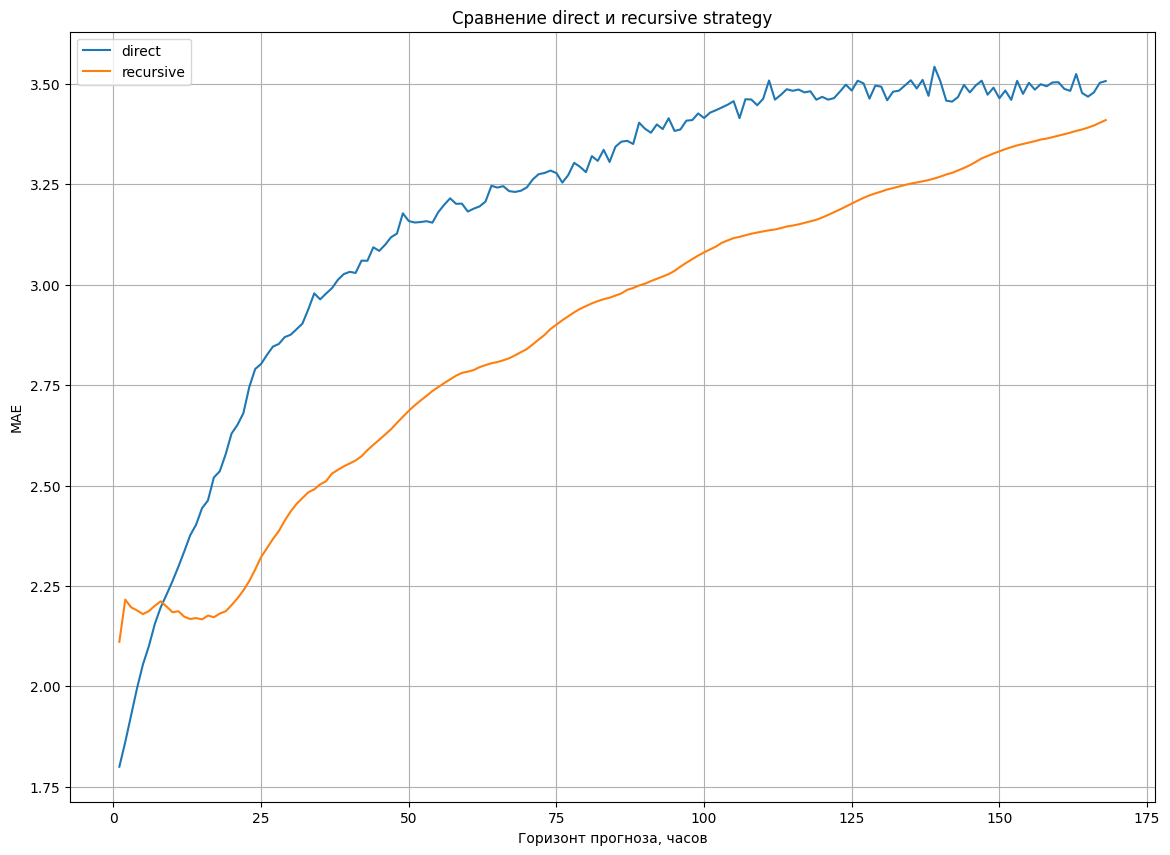

In [52]:
import matplotlib.pyplot as plt

for strategy, data in mae_by_horizon.groupby("strategy"):
    plt.plot(
        data["horizon"],
        data["MAE"],
        label=strategy
    )

plt.xlabel("Горизонт прогноза, часов")
plt.ylabel("MAE")
plt.title("Сравнение direct и recursive strategy")
plt.legend()
plt.grid()

plt.show()

## Вывод

В ходе экспериментов было установлено, что качество прогнозирования зависит от горизонта прогноза.
На малых горизонтах direct strategy показывает более низкие значения MAE и обеспечивает более точный краткосрочный прогноз. Однако с увеличением горизонта ошибка для обеих стратегий постепенно возрастает, что является ожидаемым поведением для задач прогнозирования временных рядов.
На больших горизонтах recursive strategy показала более устойчивое поведение: рост ошибки происходил медленнее, а итоговые значения MAE оказались сопоставимыми или немного ниже по сравнению с direct strategy.
Среди рассмотренных моделей наилучшие результаты продемонстрировал Gradient Boosting. Random Forest также показал хорошие результаты, тогда как одиночное дерево решений оказалось менее точным.
Таким образом:
- direct strategy лучше подходит для краткосрочного прогноза;
- recursive strategy показывает более стабильное качество на дальних горизонтах;
- Gradient Boosting оказался наиболее эффективной моделью для данной задачи.

# Оценка качества прогноза с использованием дополнительных метрик

Для более полного анализа качества прогнозирования дополнительно рассчитаем следующие метрики:
- MAE - средняя абсолютная ошибка
- MAPE — средняя абсолютная процентная ошибка
- WAPE — взвешенная абсолютная процентная ошибка
- Directional Accuracy — доля правильно предсказанных направлений изменения ряда
- Directional R² — коэффициент детерминации для изменений ряда

In [60]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import ast

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def directional_accuracy(y_true, y_pred):
    true_diff = np.diff(y_true)
    pred_diff = np.diff(y_pred)
    return np.mean(np.sign(true_diff) == np.sign(pred_diff))

def directional_r2(y_true, y_pred):
    true_diff = np.diff(y_true)
    pred_diff = np.diff(y_pred)
    return r2_score(true_diff, pred_diff)

def parse_params(params):
    if isinstance(params, dict):
        return params
    if isinstance(params, str):
        return ast.literal_eval(params)
    return {}

Расчёт метрик для direct strategy:

In [61]:
direct_metrics = []

for _, row in results_df.iterrows():
    sheet = df[row["sheet"]]
    city_df = sheet[sheet["city"] == row["city"]].sort_index().copy()
    h = int(row["horizon"])
    target_col = f"target_{h}"
    city_df[target_col] = city_df["temperature_2m"].shift(-h)
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(city_df, target_col)
    params = parse_params(row["params"])
    model = get_model(row["model"], params)
    model.fit(pd.concat([X_train, X_val]), pd.concat([y_train, y_val]))
    y_pred = model.predict(X_test)
    direct_metrics.append({
        "sheet": row["sheet"],
        "city": row["city"],
        "model": row["model"],
        "strategy": "direct",
        "horizon": h,
        "MAE": mean_absolute_error(y_test, y_pred),
        "WAPE": wape(y_test.values, y_pred),
        "MAPE": mape(y_test.values, y_pred),
        "Directional Accuracy": directional_accuracy(y_test.values, y_pred),
        "Directional R2": directional_r2(y_test.values, y_pred)
    })

direct_metrics_df = pd.DataFrame(direct_metrics)
direct_metrics_df

KeyboardInterrupt: 

In [63]:
direct_metrics_partial_df = pd.DataFrame(direct_metrics)
direct_metrics_partial_df.to_csv("direct_metrics_partial.csv", index=False)
direct_metrics_partial_df

,sheet,city,model,strategy,horizon,MAE,WAPE,MAPE,Directional Accuracy,Directional R2
0,Лист1,Благовещенск,Decision Tree,direct,1,2.323938,0.154733,56.769848,0.323674,-0.202573
1,Лист1,Благовещенск,Decision Tree,direct,2,2.401390,0.159890,58.606147,0.379998,-0.277237
2,Лист1,Благовещенск,Decision Tree,direct,3,2.379998,0.158466,58.186954,0.330210,-0.180034
3,Лист1,Благовещенск,Decision Tree,direct,4,2.516286,0.167540,62.399730,0.263427,-0.129121
4,Лист1,Благовещенск,Decision Tree,direct,5,2.611168,0.173858,60.821308,0.380325,-0.279054
...,...,...,...,...,...,...,...,...,...,...
2418,Лист3_смешанные_типы,Санкт-Петербург,Gradient Boosting,direct,67,3.115923,0.354980,128.085239,0.531792,0.029638
2419,Лист3_смешанные_типы,Санкт-Петербург,Gradient Boosting,direct,68,3.112476,0.354588,130.229408,0.592758,0.040106
2420,Лист3_смешанные_типы,Санкт-Петербург,Gradient Boosting,direct,69,3.142722,0.358034,132.918454,0.537027,0.007065
2421,Лист3_смешанные_типы,Санкт-Петербург,Gradient Boosting,direct,70,3.153447,0.359255,135.614327,0.615334,0.021702


In [64]:
done = set(
    zip(
        direct_metrics_partial_df["sheet"],
        direct_metrics_partial_df["city"],
        direct_metrics_partial_df["model"],
        direct_metrics_partial_df["horizon"]
    )
)

direct_metrics = direct_metrics_partial_df.to_dict("records")

for _, row in results_df.iterrows():

    key = (
        row["sheet"],
        row["city"],
        row["model"],
        row["horizon"]
    )

    if key in done:
        continue

    sheet = df[row["sheet"]]

    city_df = sheet[
        sheet["city"] == row["city"]
    ].sort_index().copy()

    h = int(row["horizon"])

    target_col = f"target_{h}"

    city_df[target_col] = city_df["temperature_2m"].shift(-h)

    X_train, X_val, X_test, y_train, y_val, y_test = split_data(
        city_df,
        target_col
    )

    params = parse_params(row["params"])

    model = get_model(row["model"], params)

    model.fit(
        pd.concat([X_train, X_val]),
        pd.concat([y_train, y_val])
    )

    y_pred = model.predict(X_test)

    direct_metrics.append({
        "sheet": row["sheet"],
        "city": row["city"],
        "model": row["model"],
        "strategy": "direct",
        "horizon": h,
        "MAE": mean_absolute_error(y_test, y_pred),
        "WAPE": wape(y_test.values, y_pred),
        "MAPE": mape(y_test.values, y_pred),
        "Directional Accuracy": directional_accuracy(y_test.values, y_pred),
        "Directional R2": directional_r2(y_test.values, y_pred)
    })

    if len(direct_metrics) % 50 == 0:
        print(len(direct_metrics))

direct_metrics_df = pd.DataFrame(direct_metrics)

direct_metrics_df.to_csv(
    "direct_metrics_final.csv",
    index=False
)

direct_metrics_df

2450
2500
2550
2600
2650
2700
2750
2800
2850
2900
2950
3000


,sheet,city,model,strategy,horizon,MAE,WAPE,MAPE,Directional Accuracy,Directional R2
0,Лист1,Благовещенск,Decision Tree,direct,1,2.323938,0.154733,56.769848,0.323674,-0.202573
1,Лист1,Благовещенск,Decision Tree,direct,2,2.401390,0.159890,58.606147,0.379998,-0.277237
2,Лист1,Благовещенск,Decision Tree,direct,3,2.379998,0.158466,58.186954,0.330210,-0.180034
3,Лист1,Благовещенск,Decision Tree,direct,4,2.516286,0.167540,62.399730,0.263427,-0.129121
4,Лист1,Благовещенск,Decision Tree,direct,5,2.611168,0.173858,60.821308,0.380325,-0.279054
...,...,...,...,...,...,...,...,...,...,...
3019,Лист3_смешанные_типы,Сочи,Gradient Boosting,direct,164,2.948055,0.206925,71.850030,0.575751,0.126416
3020,Лист3_смешанные_типы,Сочи,Gradient Boosting,direct,165,2.958634,0.207668,73.044199,0.613435,0.126664
3021,Лист3_смешанные_типы,Сочи,Gradient Boosting,direct,166,2.931628,0.205772,71.590801,0.631021,0.121286
3022,Лист3_смешанные_типы,Сочи,Gradient Boosting,direct,167,2.881949,0.202278,71.505423,0.640813,0.125723


Сравнение direct strategy по метрикам:

In [66]:
direct_metrics_df.groupby(["strategy", "model"])[
    ["MAE", "WAPE", "MAPE", "Directional Accuracy", "Directional R2"]
].mean()

MAE  ...  Directional R2
strategy model                        ...                
direct   Decision Tree      3.327398  ...       -0.264417
         Gradient Boosting  3.066371  ...        0.047740
         Random Forest      3.156869  ...       -0.017683

[3 rows x 5 columns]

Расчёт метрик для recursive strategy:

In [ ]:
def directional_r2(y_true, y_pred):
    true_diff = np.diff(y_true)
    pred_diff = np.diff(y_pred)
    if len(true_diff) < 5:
        return np.nan
    if np.var(true_diff) < 1e-8:
        return np.nan
    return r2_score(true_diff, pred_diff)

def wape(y_true, y_pred):
    denom = np.sum(np.abs(y_true))
    if denom < 1e-8:
        return np.nan
    return np.sum(np.abs(y_true - y_pred)) / denom

recursive_metrics = []

for name, sheet in df.items():
    if sheet.index.name == "ds" and "city" in sheet.columns:
        for city, city_df in sheet.groupby("city"):
            city_df = city_df.sort_index().copy()
            city_df["target_1"] = city_df["temperature_2m"].shift(-1)
            X_train, X_val, X_test, y_train, y_val, y_test = split_data(city_df, "target_1")
            test_index = X_test.index
            origins = test_index[:-168:168]
            for model_name in models:
                params_row = recursive_results_df[
                    (recursive_results_df["city"] == city) &
                    (recursive_results_df["model"] == model_name)
                ].iloc[0]
                params = parse_params(params_row["params"])
                model = get_model(model_name, params)
                model.fit(pd.concat([X_train, X_val]), pd.concat([y_train, y_val]))
                for origin in origins:
                    history = city_df.loc[:origin, "temperature_2m"].values
                    if len(history) < 168:
                        continue
                    y_pred = recursive_forecast(model, history, origin, 168)
                    y_true = city_df.loc[
                        origin + pd.Timedelta(hours=1):
                        origin + pd.Timedelta(hours=168),
                        "temperature_2m"
                    ].values
                    if len(y_true) < 168:
                        continue
                    for h in horizons:
                        recursive_metrics.append({
                            "sheet": name,
                            "city": city,
                            "model": model_name,
                            "strategy": "recursive",
                            "horizon": h,
                            "MAE": mae(y_true[:h], y_pred[:h]),
                            "WAPE": wape(y_true[:h], y_pred[:h]),
                            "MAPE": mape(y_true[:h], y_pred[:h]),
                            "Directional Accuracy": directional_accuracy(y_true[:h], y_pred[:h]),
                            "Directional R2": directional_r2(y_true[:h], y_pred[:h])
                        })
                        print(len(recursive_metrics))

recursive_metrics_df = pd.DataFrame(recursive_metrics)
recursive_metrics_df

Directional R^2 может принимать отрицательные значения. Это означает, что модель предсказывает изменения временного ряда хуже, чем простая базовая модель, использующая среднее изменение. Для коротких горизонтов и почти неизменяющихся участков ряда эта метрика может быть нестабильной, поэтому дополнительно использовалась метрика Directional Accuracy.

In [70]:
recursive_metrics_df.to_csv("recursive_metrics_final.csv", index=False)

Почистим некорректные значения Directional R^2, которые могли появиться при делении на очень маленькие значения:

In [72]:
recursive_metrics_df["Directional R2"] = recursive_metrics_df["Directional R2"].replace([np.inf, -np.inf], np.nan)
recursive_metrics_df.loc[recursive_metrics_df["Directional R2"].abs() > 1e6, "Directional R2"] = np.nan

Почистим некорректные значения WAPE:

In [78]:
recursive_metrics_df["WAPE"] = recursive_metrics_df["WAPE"].replace([np.inf, -np.inf], np.nan)

Сравнение recursive strategy по метрикам:

In [86]:
recursive_metrics_df.groupby(["strategy", "model"])[
    ["MAE", "WAPE", "MAPE", "Directional Accuracy", "Directional R2"]
].mean()

MAE  ...  Directional R2
strategy  model                        ...                
recursive Decision Tree      2.994073  ...       -2.116313
          Gradient Boosting  2.795064  ...       -0.469581
          Random Forest      2.853356  ...       -0.735122

[3 rows x 5 columns]

Объединим таблицы метрик direct и recursive strategy для финального сравнения моделей и стратегий прогнозирования.

In [82]:
all_metrics = pd.concat(
    [direct_metrics_df, recursive_metrics_df],
    ignore_index=True
)

all_metrics

,sheet,city,model,strategy,horizon,MAE,WAPE,MAPE,Directional Accuracy,Directional R2
0,Лист1,Благовещенск,Decision Tree,direct,1,2.323938,0.154733,56.769848,0.323674,-0.202573
1,Лист1,Благовещенск,Decision Tree,direct,2,2.401390,0.159890,58.606147,0.379998,-0.277237
2,Лист1,Благовещенск,Decision Tree,direct,3,2.379998,0.158466,58.186954,0.330210,-0.180034
3,Лист1,Благовещенск,Decision Tree,direct,4,2.516286,0.167540,62.399730,0.263427,-0.129121
4,Лист1,Благовещенск,Decision Tree,direct,5,2.611168,0.173858,60.821308,0.380325,-0.279054
...,...,...,...,...,...,...,...,...,...,...
166315,Лист3_смешанные_типы,Сочи,Gradient Boosting,recursive,164,2.229016,0.296912,32.022917,0.539877,0.055087
166316,Лист3_смешанные_типы,Сочи,Gradient Boosting,recursive,165,2.226754,0.297429,32.103159,0.542683,0.053887
166317,Лист3_смешанные_типы,Сочи,Gradient Boosting,recursive,166,2.235136,0.299510,32.532532,0.539394,0.048664
166318,Лист3_смешанные_типы,Сочи,Gradient Boosting,recursive,167,2.240208,0.300880,32.738940,0.542169,0.050437


После объединения результатов direct и recursive strategy проанализируем изменение качества прогнозирования в зависимости от горизонта прогноза.

In [83]:
metrics_by_horizon = all_metrics.groupby(
    ["strategy", "horizon"]
)[
    ["MAE", "WAPE", "MAPE"]
].mean(numeric_only=True).reset_index()

metrics_by_horizon

,strategy,horizon,MAE,WAPE,MAPE
0,direct,1,1.799858,0.152565,57.081041
1,direct,2,1.861340,0.157901,58.850060
2,direct,3,1.928858,0.163635,61.414909
3,direct,4,1.995640,0.169465,63.590520
4,direct,5,2.054817,0.174479,64.976937
...,...,...,...,...,...
331,recursive,164,3.386568,0.476887,104.462533
332,recursive,165,3.391251,0.477183,104.580379
333,recursive,166,3.396396,0.477845,104.706601
334,recursive,167,3.403270,0.478340,104.977330


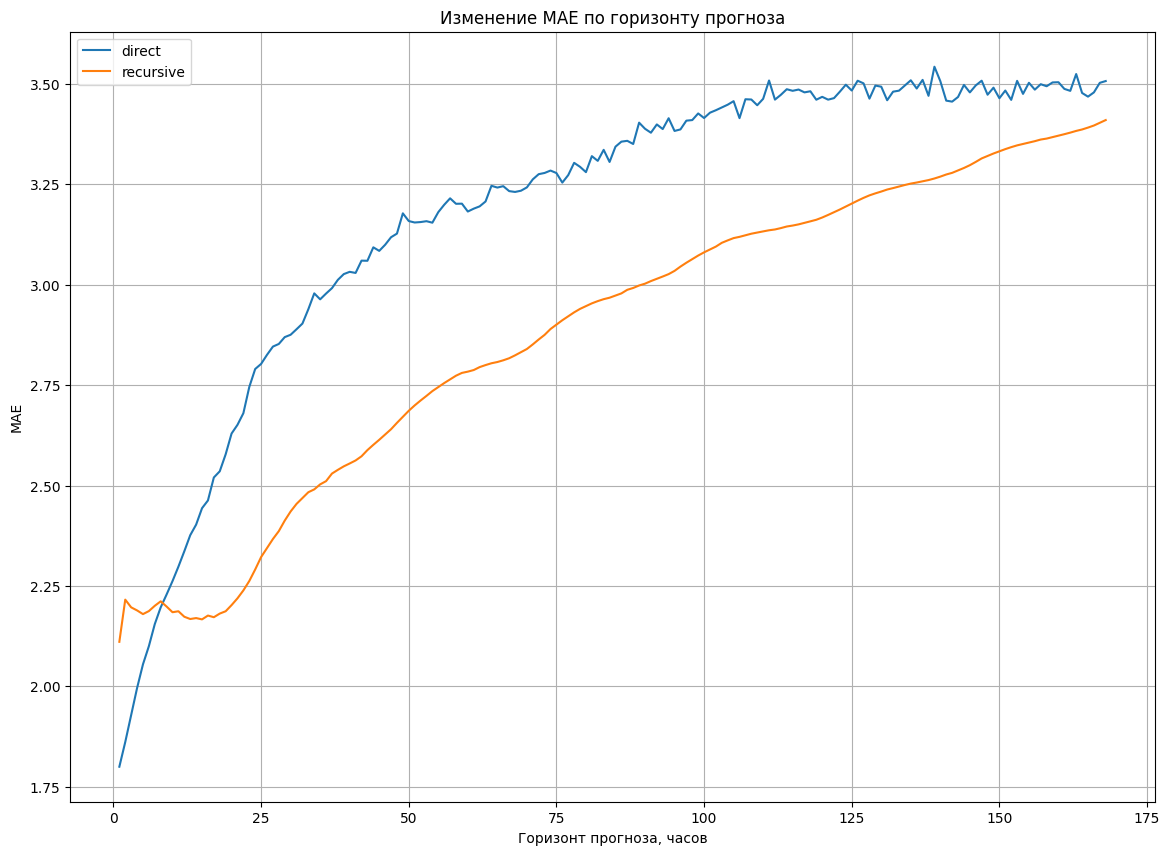

In [84]:
import matplotlib.pyplot as plt

for strategy, data in metrics_by_horizon.groupby("strategy"):
    plt.plot(
        data["horizon"],
        data["MAE"],
        label=strategy
    )

plt.xlabel("Горизонт прогноза, часов")
plt.ylabel("MAE")
plt.title("Изменение MAE по горизонту прогноза")
plt.legend()
plt.grid()

plt.show()

По графику видно, что ошибка MAE увеличивается с ростом горизонта прогнозирования. Это ожидаемо для многошагового прогноза: чем дальше прогноз, тем выше неопределённость. На коротких горизонтах direct strategy показывает более низкую ошибку, однако на дальних горизонтах recursive strategy демонстрирует более стабильное поведение.

Сделаем финальное усреднение метрик для каждой стратегии и модели:

In [77]:
all_metrics.groupby(
    ["strategy", "model"]
)[
    ["MAE", "WAPE", "MAPE", "Directional Accuracy", "Directional R2"]
].mean(numeric_only=True)

MAE  ...  Directional R2
strategy  model                        ...                
direct    Decision Tree      3.327398  ...       -0.264417
          Gradient Boosting  3.066371  ...        0.047740
          Random Forest      3.156869  ...       -0.017683
recursive Decision Tree      2.994073  ...       -2.116313
          Gradient Boosting  2.795064  ...       -0.469581
          Random Forest      2.853356  ...       -0.735122

[6 rows x 5 columns]

In [85]:
all_metrics.to_csv("all_metrics_final.csv", index=False)

# Вывод

В ходе экспериментов было проведено сравнение direct и recursive strategy для задачи многошагового прогнозирования температуры.

По метрикам MAE и MAPE recursive strategy показала более высокое качество прогнозирования. Наилучший результат продемонстрировала модель Gradient Boosting:

- recursive + Gradient Boosting — MAE = 2.80;
- direct + Gradient Boosting — MAE = 3.07.

Это показывает, что recursive strategy обеспечивает более точный прогноз по абсолютной ошибке.

Однако по метрикам Directional Accuracy и Directional R^2 direct strategy показала более стабильное качество прогнозирования направления изменения временного ряда. Особенно хорошо себя показал Gradient Boosting, для которого Directional R^2 оказался положительным.

Также было замечено, что ошибка прогнозирования увеличивается с ростом горизонта прогноза, что является ожидаемым поведением для задач временных рядов.

Среди рассмотренных моделей:

- наилучшие результаты показал Gradient Boosting;
- Random Forest показал близкое качество;
- одиночное дерево решений оказалось наименее точным.

Таким образом:

- recursive strategy лучше подходит для минимизации абсолютной ошибки прогноза;
- direct strategy демонстрирует более устойчивое качество при прогнозировании направления изменения ряда;
- Gradient Boosting оказался наиболее эффективной моделью для данной задачи.

В ходе лабораторной работы были выполнены:
- извлечение и восстановление данных из Excel-файла;
- очистка временных рядов и обработка пропусков;
- анализ стационарности, сезонности и спектральных характеристик;
- построение признаков для прогнозирования;
- обучение моделей Decision Tree, Random Forest и Gradient Boosting;
- сравнение direct и recursive strategy для многошагового прогнозирования температуры на неделю вперёд.

Наилучшие результаты показал Gradient Boosting. По метрикам MAE и MAPE recursive strategy обеспечила более точный прогноз, тогда как direct strategy показала более устойчивое качество прогнозирования направления изменения временного ряда.

Также было установлено, что ошибка прогнозирования увеличивается с ростом горизонта прогноза, что является ожидаемым поведением для задач временных рядов.